# 🎓 OULAD Student Performance Prediction
## End-to-End ML Pipeline — Full Feature Extraction Edition
> **Dataset**: Open University Learning Analytics Dataset (OULAD)  
> **Goal**: Predict student at-risk status with maximum accuracy & explainability  
> **Features**: ALL 7 tables fully exploited — VLE windows, registration timing, module-normalized engagement  
> **Models**: 9 classifiers + Optuna tuning + Ensemble + SHAP explainability


---
## ⚙️ SECTION 0 — Setup & Configuration

In [1]:
# ── Installs (run once) ──────────────────────────────────────
# !pip install category_encoders optuna shap imbalanced-learn xgboost lightgbm kaleido pyarrow joblib


In [2]:
import os, warnings, time
import numpy  as np
import pandas as pd
import matplotlib.pyplot    as plt
import matplotlib.ticker    as mtick
import seaborn              as sns
import plotly.express       as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

In [3]:

# Encoding
from sklearn.preprocessing   import OrdinalEncoder, LabelEncoder, StandardScaler, MinMaxScaler
import category_encoders     as ce

# Modeling
from sklearn.model_selection  import train_test_split, StratifiedKFold, cross_val_score, learning_curve
from sklearn.metrics          import (
    accuracy_score, f1_score, roc_auc_score, precision_score, recall_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay, RocCurveDisplay,
    precision_recall_curve, average_precision_score
)
from sklearn.linear_model     import LogisticRegression
from sklearn.ensemble         import RandomForestClassifier, GradientBoostingClassifier, VotingClassifier
from sklearn.svm              import SVC
from sklearn.neighbors        import KNeighborsClassifier
from sklearn.neural_network   import MLPClassifier
from sklearn.tree             import DecisionTreeClassifier
from sklearn.calibration      import CalibratedClassifierCV
from sklearn.inspection       import permutation_importance

# Imbalance
from imblearn.over_sampling   import SMOTE, SMOTENC
from imblearn.combine         import SMOTETomek
from imblearn.pipeline        import Pipeline as ImbPipe
from imblearn.under_sampling  import TomekLinks

# Boosting
import xgboost  as xgb
import lightgbm as lgb

# Explainability
import shap

# Tuning
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

# Misc
import joblib

In [4]:

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 60)
pd.set_option('display.float_format', '{:.3f}'.format)

# ── Global style ─────────────────────────────────────────────
CLR = dict(
    Pass        = '#4CC9F0',
    Distinction = '#4361EE',
    Fail        = '#F72585',
    Withdrawn   = '#7209B7',
    palette     = ['#4361EE','#F72585','#4CC9F0','#7209B7','#3A0CA3','#F3722C','#06D6A0','#FFD166','#EF476F','#118AB2']
)

plt.rcParams.update({
    'figure.facecolor': 'white', 'axes.facecolor': 'white',
    'axes.grid': True, 'grid.alpha': 0.25,
    'axes.spines.top': False, 'axes.spines.right': False,
    'font.size': 11,
})

SEED      = 42
DATA_PATH = './'   # ← CSV files location



---
##  SECTION 1 — Data Loading & Profiling

In [5]:
FILES = {
    'student_info'        : 'studentInfo.csv',
    'student_vle'         : 'studentVle.csv',
    'student_assessment'  : 'studentAssessment.csv',
    'student_registration': 'studentRegistration.csv',
    'assessments'         : 'assessments.csv',
    'vle'                 : 'vle.csv',
    'courses'             : 'courses.csv',
}

T = {}
print('Loading tables:\n')
for key, fname in FILES.items():
    path = os.path.join(DATA_PATH, fname)
    if os.path.exists(path):
        T[key] = pd.read_csv(path)
        r, c   = T[key].shape
        mem    = T[key].memory_usage(deep=True).sum() / 1e6
        print(f'  {fname:<35}  {r:>8,} rows × {c} cols   ({mem:.1f} MB)')
    else:
        print(f'{fname} — NOT FOUND')

si    = T['student_info'].copy()
sv    = T['student_vle'].copy()
sa    = T['student_assessment'].copy()
reg   = T['student_registration'].copy()
asmts = T['assessments'].copy()
vle   = T['vle'].copy()

print(f'\n  studentInfo columns : {si.columns.tolist()}')
print(f'  Target classes      : {si["final_result"].unique()}')
print(f'  Total students      : {si["id_student"].nunique():,}')


Loading tables:

  studentInfo.csv                        32,593 rows × 12 cols   (19.4 MB)
  studentVle.csv                       10,655,280 rows × 6 cols   (1640.9 MB)
  studentAssessment.csv                 173,912 rows × 5 cols   (7.0 MB)
  studentRegistration.csv                32,593 rows × 5 cols   (4.8 MB)
  assessments.csv                           206 rows × 6 cols   (0.0 MB)
  vle.csv                                 6,364 rows × 6 cols   (1.3 MB)
  courses.csv                                22 rows × 3 cols   (0.0 MB)

  studentInfo columns : ['code_module', 'code_presentation', 'id_student', 'gender', 'region', 'highest_education', 'imd_band', 'age_band', 'num_of_prev_attempts', 'studied_credits', 'disability', 'final_result']
  Target classes      : ['Pass' 'Withdrawn' 'Fail' 'Distinction']
  Total students      : 28,785


In [6]:
# ── Detailed data profiling ──────────────────────────────────
print('\n DATA PROFILING REPORT')
print('='*65)

for name, df in T.items():
    miss = df.isnull().sum()
    miss = miss[miss > 0]
    dups = df.duplicated().sum()
    print(f'\n  [{name}]  shape={df.shape}')
    print(f'    Duplicates : {dups:,}')
    if len(miss):
        for col, n in miss.items():
            print(f'    Missing    : {col} → {n:,} ({n/len(df):.1%})')
    else:
        print(f'    Missing    : None ')

print('\n' + '='*65)
print('  Profiling complete')



 DATA PROFILING REPORT

  [student_info]  shape=(32593, 12)
    Duplicates : 0
    Missing    : imd_band → 1,111 (3.4%)

  [student_vle]  shape=(10655280, 6)
    Duplicates : 787,170
    Missing    : None 

  [student_assessment]  shape=(173912, 5)
    Duplicates : 0
    Missing    : score → 173 (0.1%)

  [student_registration]  shape=(32593, 5)
    Duplicates : 0
    Missing    : date_registration → 45 (0.1%)
    Missing    : date_unregistration → 22,521 (69.1%)

  [assessments]  shape=(206, 6)
    Duplicates : 0
    Missing    : date → 11 (5.3%)

  [vle]  shape=(6364, 6)
    Duplicates : 0
    Missing    : week_from → 5,243 (82.4%)
    Missing    : week_to → 5,243 (82.4%)

  [courses]  shape=(22, 3)
    Duplicates : 0
    Missing    : None 

  Profiling complete


---
##  SECTION 2 — EDA: Target & Demographics

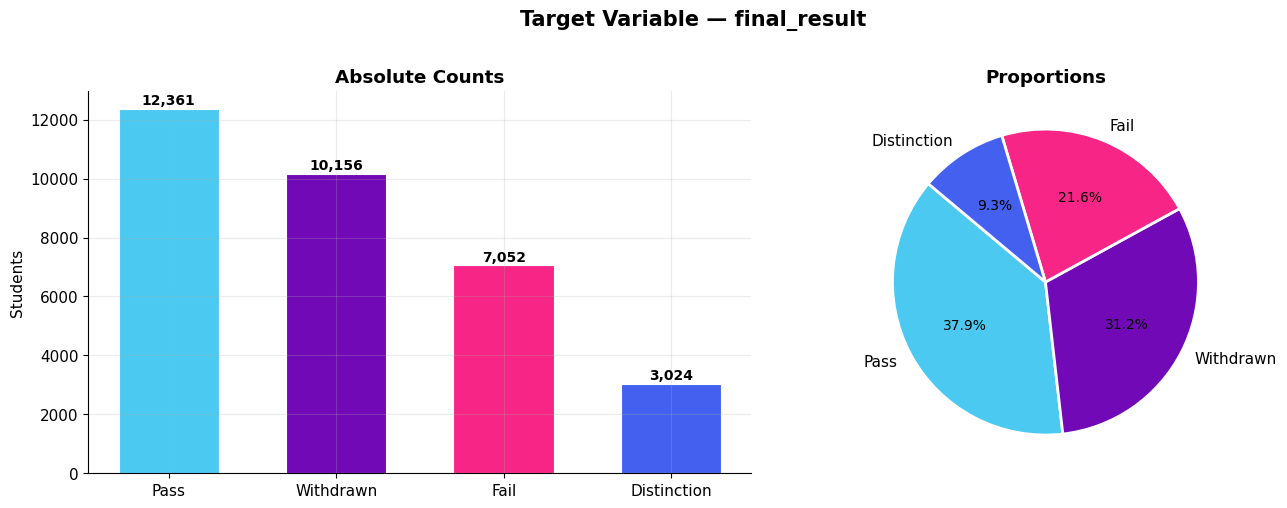


CLASS IMBALANCE ANALYSIS
   Success (Pass+Distinction) : 15,385  (47.2%)
   At-Risk (Fail+Withdrawn)   : 17,208  (52.8%)
   Imbalance ratio            : 1.12x  →  SMOTE required


In [7]:
# ── Fig 1 · Target distribution ─────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Target Variable — final_result', fontsize=15, fontweight='bold', y=1.01)

counts = si['final_result'].value_counts()
c_list = [CLR.get(r, '#888') for r in counts.index]

bars = axes[0].bar(counts.index, counts.values, color=c_list, edgecolor='white', linewidth=.8, width=.6)
axes[0].set_title('Absolute Counts', fontweight='bold')
axes[0].set_ylabel('Students')
for p in bars:
    axes[0].annotate(f'{int(p.get_height()):,}',
                     (p.get_x() + p.get_width()/2, p.get_height() + 50),
                     ha='center', va='bottom', fontsize=10, fontweight='bold')

wedges, texts, autotexts = axes[1].pie(
    counts.values, labels=counts.index, colors=c_list,
    autopct='%1.1f%%', startangle=140,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2})
for at in autotexts: at.set_fontsize(10)
axes[1].set_title('Proportions', fontweight='bold')

plt.tight_layout()
plt.savefig('fig01_target.png', dpi=150, bbox_inches='tight')
plt.show()

# Class imbalance metrics
print('\nCLASS IMBALANCE ANALYSIS')
success = counts.get('Pass', 0) + counts.get('Distinction', 0)
atrisk  = counts.get('Fail', 0) + counts.get('Withdrawn', 0)
ratio   = max(success, atrisk) / min(success, atrisk)
print(f'   Success (Pass+Distinction) : {success:,}  ({success/len(si):.1%})')
print(f'   At-Risk (Fail+Withdrawn)   : {atrisk:,}  ({atrisk/len(si):.1%})')
print(f'   Imbalance ratio            : {ratio:.2f}x  →  SMOTE required')


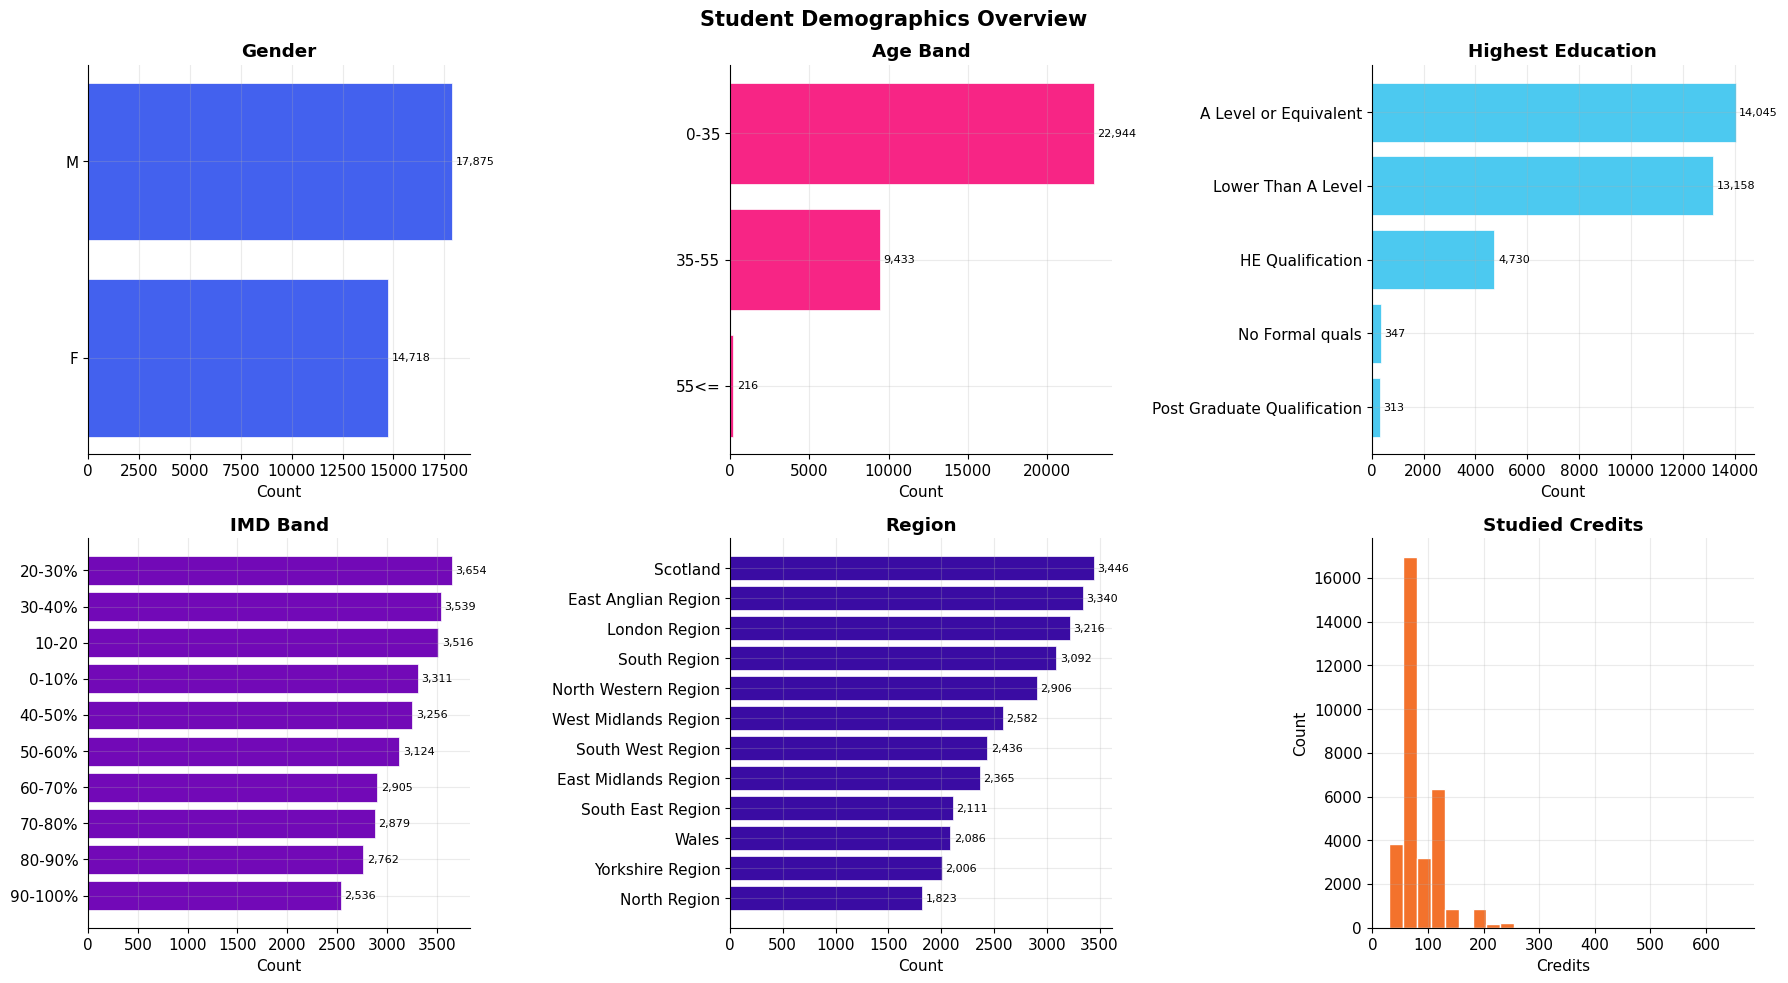

In [8]:
# ── Fig 2 · Demographics overview ───────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Student Demographics Overview', fontsize=15, fontweight='bold')

def bar_h(ax, series, title, top=12, color=None):
    vc = series.value_counts().head(top)
    c  = color or CLR['palette'][0]
    ax.barh(vc.index[::-1], vc.values[::-1], color=c, edgecolor='white', linewidth=0.5)
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Count')
    for i, (idx, val) in enumerate(zip(vc.index[::-1], vc.values[::-1])):
        ax.text(val + max(vc.values)*0.01, i, f'{val:,}', va='center', fontsize=8)

bar_h(axes[0,0], si['gender'],           'Gender',           color=CLR['palette'][0])
bar_h(axes[0,1], si['age_band'],          'Age Band',         color=CLR['palette'][1])
bar_h(axes[0,2], si['highest_education'], 'Highest Education',color=CLR['palette'][2])
bar_h(axes[1,0], si['imd_band'],          'IMD Band',         color=CLR['palette'][3])
bar_h(axes[1,1], si['region'],            'Region',           color=CLR['palette'][4])

axes[1,2].hist(si['studied_credits'].dropna(), bins=25,
               color=CLR['palette'][5], edgecolor='white')
axes[1,2].set_title('Studied Credits', fontweight='bold')
axes[1,2].set_xlabel('Credits')
axes[1,2].set_ylabel('Count')

plt.tight_layout()
plt.savefig('fig02_demographics.png', dpi=150, bbox_inches='tight')
plt.show()


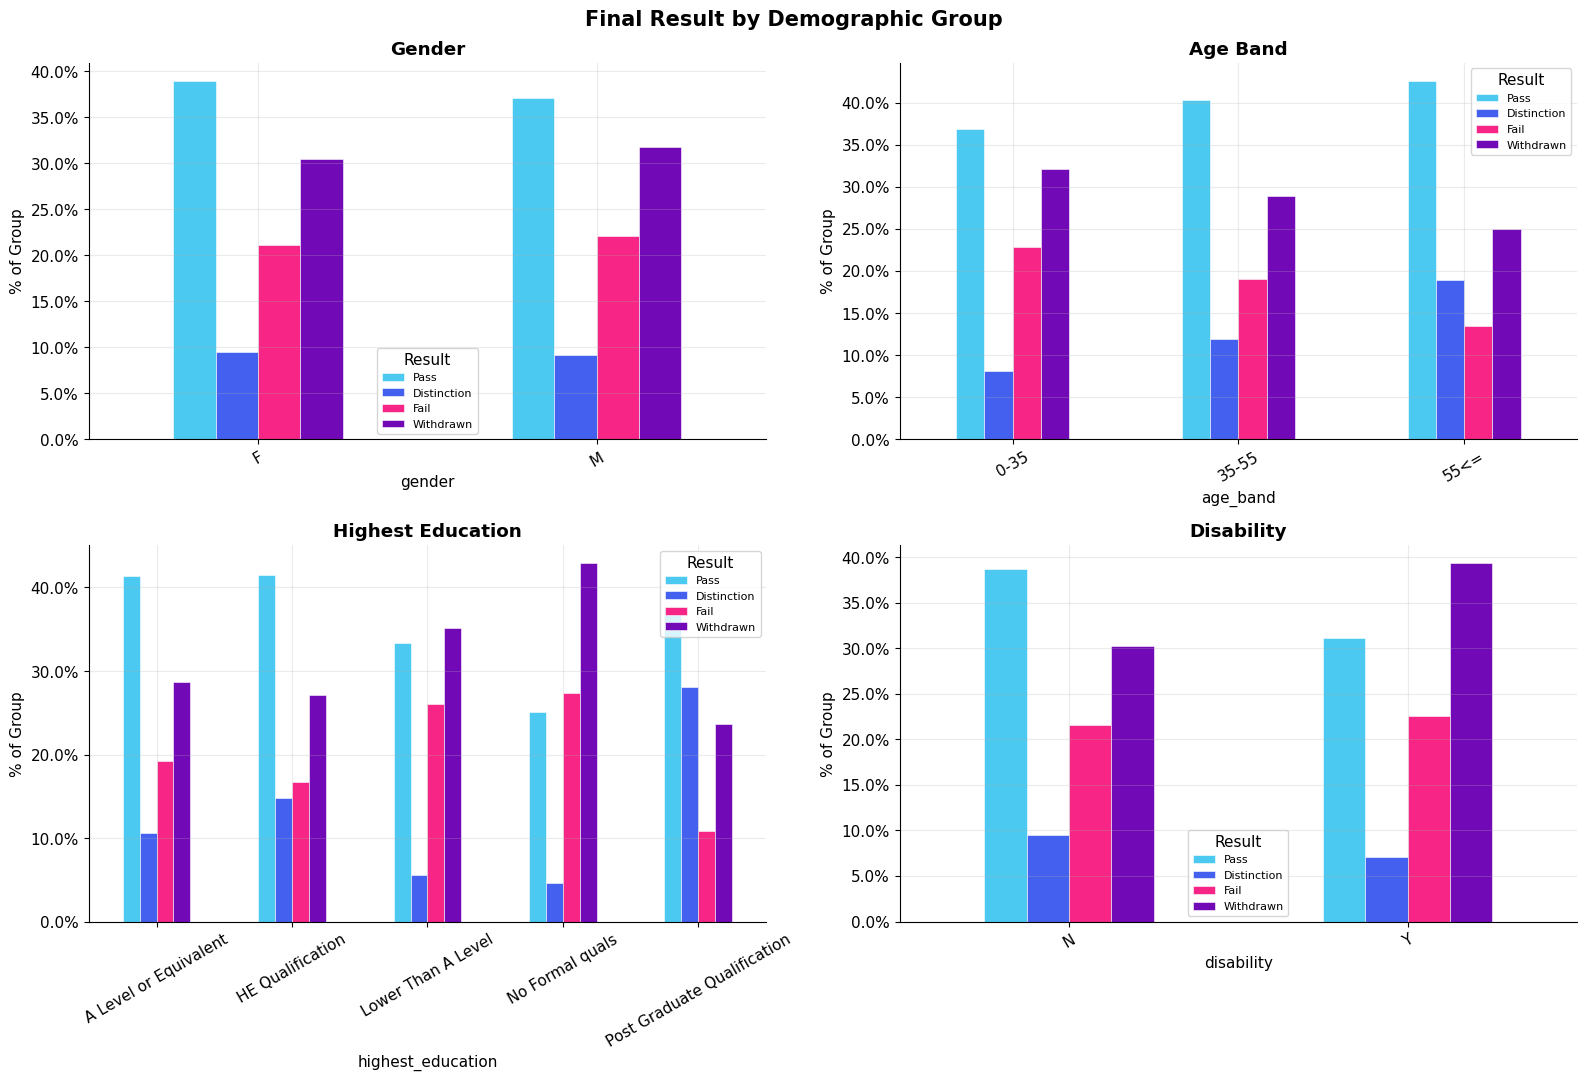

In [9]:
# ── Fig 3 · Result by demographic group ─────────────────────
fig, axes = plt.subplots(2, 2, figsize=(16, 11))
fig.suptitle('Final Result by Demographic Group', fontsize=15, fontweight='bold')

for ax, col in zip(axes.flatten(), ['gender', 'age_band', 'highest_education', 'disability']):
    ct = (pd.crosstab(si[col], si['final_result'], normalize='index') * 100
          ).reindex(columns=['Pass','Distinction','Fail','Withdrawn'], fill_value=0)
    ct.plot(kind='bar', ax=ax, color=[CLR.get(c, '#888') for c in ct.columns],
            edgecolor='white', linewidth=.4)
    ax.set_title(col.replace('_',' ').title(), fontweight='bold')
    ax.set_ylabel('% of Group')
    ax.yaxis.set_major_formatter(mtick.PercentFormatter())
    ax.legend(title='Result', fontsize=8)
    ax.tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig('fig03_result_by_demo.png', dpi=150, bbox_inches='tight')
plt.show()


---
##  SECTION 3 — EDA: VLE & Assessments

Aggregating VLE data …


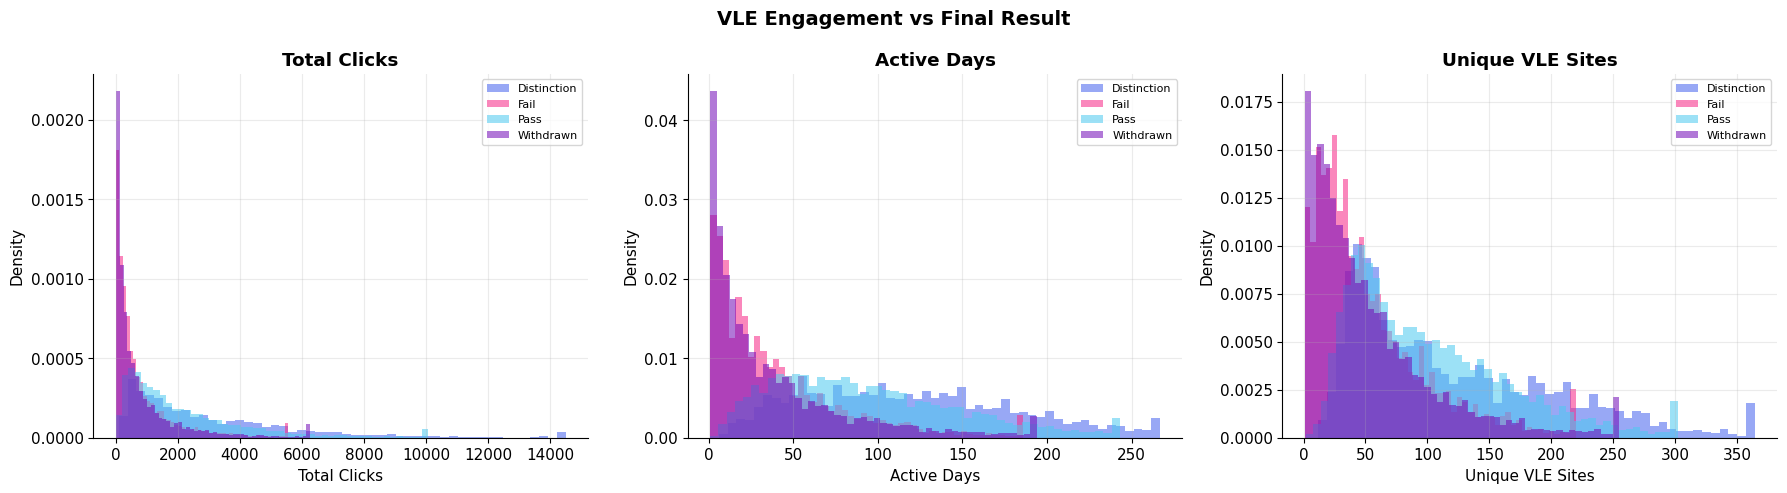

In [10]:
# ── VLE quick aggregate ──────────────────────────────────────
print('Aggregating VLE data …')
vle_quick = sv.groupby('id_student').agg(
    total_clicks = ('sum_click', 'sum'),
    active_days  = ('date', 'nunique'),
    unique_sites = ('id_site', 'nunique'),
).reset_index()
si_v = si.merge(vle_quick, on='id_student', how='left')

# ── Fig 4 · VLE engagement ───────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('VLE Engagement vs Final Result', fontsize=14, fontweight='bold')

for ax, col, label in zip(axes,
    ['total_clicks', 'active_days', 'unique_sites'],
    ['Total Clicks',  'Active Days', 'Unique VLE Sites']):
    for res, grp in si_v.groupby('final_result'):
        d = grp[col].clip(upper=grp[col].quantile(.99))
        ax.hist(d, bins=50, alpha=.55, density=True, edgecolor='none',
                label=res, color=CLR.get(res, '#888'))
    ax.set_xlabel(label); ax.set_ylabel('Density')
    ax.set_title(label, fontweight='bold'); ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('fig04_vle_engagement.png', dpi=150, bbox_inches='tight')
plt.show()


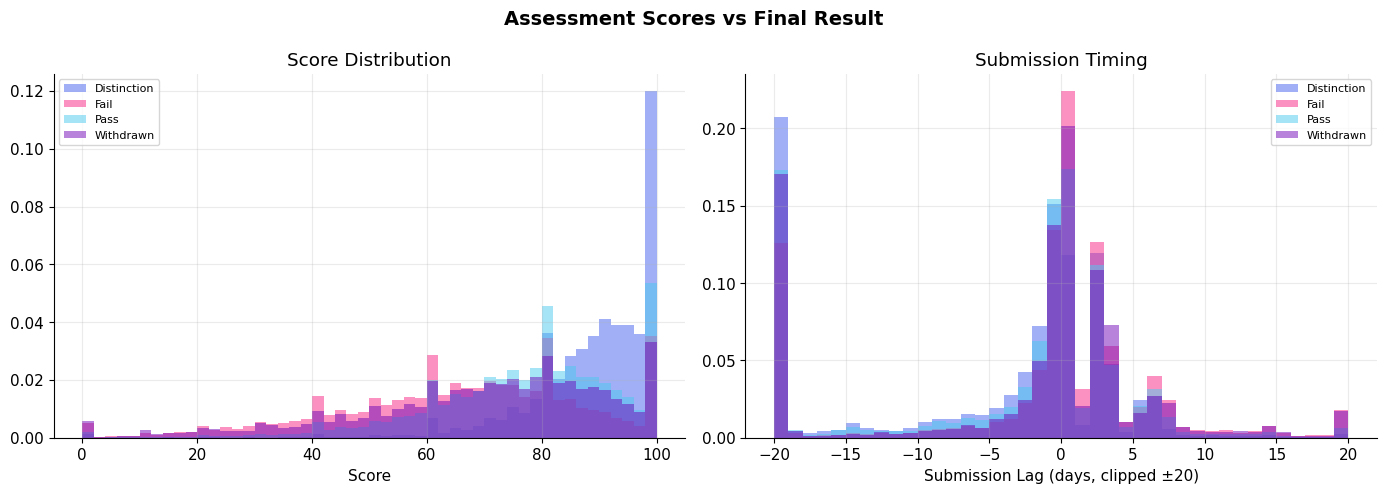

In [11]:
# ── Fig 5 · Assessments ──────────────────────────────────────
sa_m = sa.merge(si[['id_student', 'final_result']], on='id_student', how='left')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Assessment Scores vs Final Result', fontsize=14, fontweight='bold')

for res, grp in sa_m.groupby('final_result'):
    axes[0].hist(grp['score'].dropna(), bins=50, alpha=.5, density=True,
                 edgecolor='none', label=res, color=CLR.get(res, '#888'))
axes[0].set_xlabel('Score'); axes[0].set_title('Score Distribution'); axes[0].legend(fontsize=8)

sa_m2 = sa_m.merge(asmts[['id_assessment','date']].rename(columns={'date':'due_date'}),
                   on='id_assessment', how='left')
sa_m2['lag'] = sa_m2['date_submitted'] - sa_m2['due_date']
for res, grp in sa_m2.groupby('final_result'):
    axes[1].hist(grp['lag'].dropna().clip(-20, 20), bins=40, alpha=.5, density=True,
                 edgecolor='none', label=res, color=CLR.get(res, '#888'))
axes[1].set_xlabel('Submission Lag (days, clipped ±20)')
axes[1].set_title('Submission Timing'); axes[1].legend(fontsize=8)

plt.tight_layout()
plt.savefig('fig05_assessments.png', dpi=150, bbox_inches='tight')
plt.show()


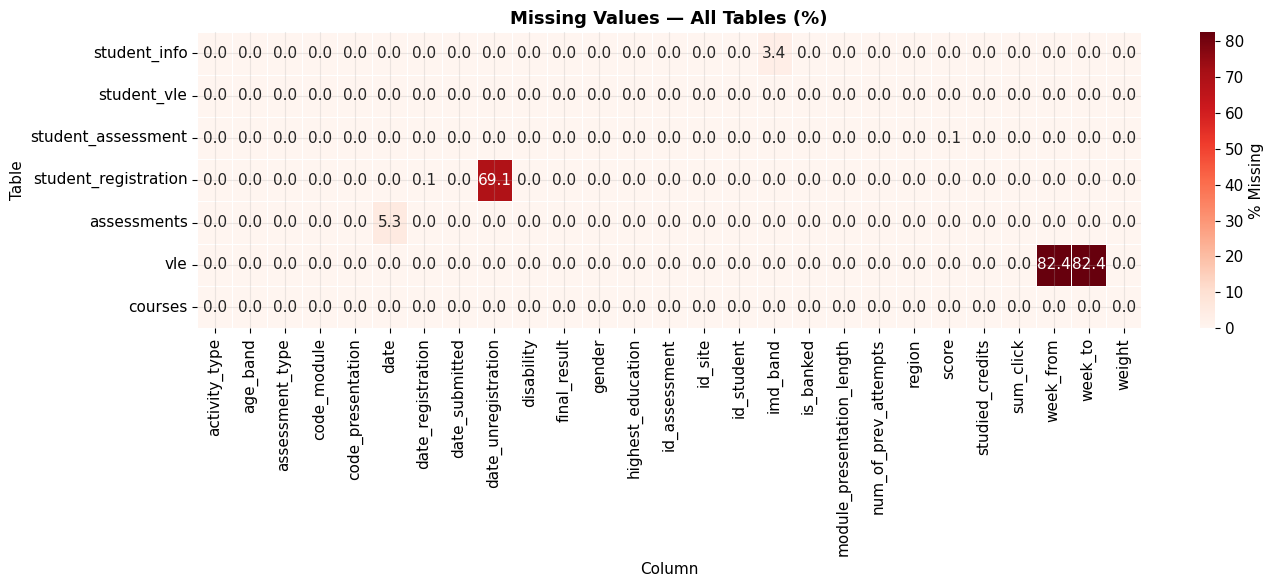

EDA complete — 6 figures saved


In [12]:
# ── Fig 6 · Missing values heatmap ──────────────────────────
all_miss = {name: (df.isnull().mean()*100).rename(name) for name, df in T.items()}
miss_df  = pd.DataFrame(all_miss).fillna(0)

fig, ax = plt.subplots(figsize=(14, 6))
sns.heatmap(miss_df.T, annot=True, fmt='.1f', cmap='Reds',
            linewidths=.5, ax=ax, cbar_kws={'label': '% Missing'})
ax.set_title('Missing Values — All Tables (%)', fontsize=13, fontweight='bold')
ax.set_xlabel('Column'); ax.set_ylabel('Table')
plt.tight_layout()
plt.savefig('fig06_missing_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

print('EDA complete — 6 figures saved')


---
##  SECTION 4 — Advanced Cleaning & Encoding

In [13]:


#3mlna copy men el data 3ashan neshtaghl 3liha fa manbwzsh el original data noskha men gadwal student info 
df = si.copy()

# Remove duplicates 3ashan nafs el taleb law etkrr aktar men mara el model bitlkhbt 
df.drop_duplicates(inplace=True)

# Fill missing values fy students el kima bt3thom msh mawgoda fa 7awlnaha unknow 
df['imd_band'] = df['imd_band'].fillna('Unknown')
##Encoding part leh 3ashan machine learning mabifhmsh kalam bifhm arkam

# Ordinal Encoding:imd_band fy tartrib tabi3y fa hawlnahom l arkam 3ashan yefhmo imd(mestawa el mae3isha bet3thom)
imd_map = {
    '0-10%':0, '10-20%':1, '20-30%':2,
    '30-40%':3, '40-50%':4,
    '50-60%':5, '60-70%':6,
    '70-80%':7, '80-90%':8,
    '90-100%':9,
    'Unknown':-1
}
#ordinal Encoding:3mlna brdo ordinal encoding ll education level 3ashan fi tarteb f rakmnahom

edu_map = {
    'No Formal quals':0,
    'Lower Than A Level':1,
    'A Level or Equivalent':2,
    'HE Qualification':3,
    'Post Graduate Qualification':4
}
#ordinal Encoding:3mlna brdo ordinal encoding  ll fe2a el 3omrya rakmnahom

age_map = {
    '0-35':0,
    '35-55':1,
    '55<=':2
}
#3AMAL MAPPING BI7AWLHOM MSH AKTAR

df['imd_num'] = df['imd_band'].map(imd_map)
df['edu_num'] = df['highest_education'].map(edu_map)
df['age_num'] = df['age_band'].map(age_map)

# Binary Encoding: LEH 3ASHAN hwa hagteen female aw male fa we don't need ordinal yes or no fekrto
df['is_male'] = (df['gender'] == 'M').astype(int)
df['is_disabled'] = (df['disability'] == 'Y').astype(int)

# Targets
## hena 7awelna el final result le 4 classes b numbers 
# 3ashan el model mayefhamsh text
df['target_4'] = df['final_result'].map({
    'Pass':0,
    'Distinction':1,
    'Fail':2,
    'Withdrawn':3
})
## hena basetna el target le binary classification
# successful students = 0
# risky students = 1

df['target_bin'] = df['final_result'].apply(
    lambda x: 0 if x in ['Pass','Distinction'] else 1
)

# One-hot encoding:# one-hot encoding lel categorical columns
# 3ashan code_module w region mafesh benhom tarteb
## kol category bett7awel le column لوحدها
# w el values بتكون 0 أو 1
df = pd.get_dummies(
    df,
    columns=['code_module', 'region'],
    drop_first=True
)

# Simple encoding for presentation:# ne7awel code_presentation le arkam
# 3ashan el machine learning mayefhamsh text
df['presentation_enc'] = df['code_presentation'].astype('category').cat.codes

# Drop old columns
## nshoof el categorical columns el adeema
# 3ashan ba2a 3andna encoded columns  7awlna kol el categorial col l num b 2stkhdam encoding
# f 3mlna drop ll 2odam w badlnahom bel godad masbnash el odam 3ashan mai7slsh laghbta
drop_cols = [
    'gender',
    'age_band',
    'highest_education',
    'imd_band',
    'disability',
    'final_result',
    'code_presentation'
]

df.drop(columns=drop_cols, inplace=True)

# Fill remaining missing values
df.fillna(0, inplace=True)

print(df.shape)

df.head(10)

(32593, 29)


,id_student,num_of_prev_attempts,studied_credits,imd_num,edu_num,age_num,is_male,is_disabled,target_4,target_bin,code_module_BBB,code_module_CCC,code_module_DDD,code_module_EEE,code_module_FFF,code_module_GGG,region_East Midlands Region,region_Ireland,region_London Region,region_North Region,region_North Western Region,region_Scotland,region_South East Region,region_South Region,region_South West Region,region_Wales,region_West Midlands Region,region_Yorkshire Region,presentation_enc
0,11391,0,240,9.000,3,2,1,0,0,0,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,1
1,28400,0,60,2.000,3,1,0,0,0,0,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,1
2,30268,0,60,3.000,2,1,0,1,3,1,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,1
3,31604,0,60,5.000,2,1,0,0,0,0,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,1
4,32885,0,60,5.000,1,0,0,0,0,0,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,1
5,38053,0,60,8.000,2,1,1,0,0,0,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,1
6,45462,0,60,3.000,3,0,1,0,0,0,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,1
7,45642,0,120,9.000,2,0,0,0,0,0,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,1
8,52130,0,90,7.000,2,0,0,0,0,0,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,1
9,53025,0,60,-1.000,4,2,1,0,0,0,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,1


--- 
##  SECTION 5 — Advanced Feature Engineering (All 7 Tables)


In [42]:
# Feature Engineering
#da part el student engagment 
# hena bngama3 nashat kol student
vle_feat = sv.groupby('id_student').agg(

    # total clicks لكل student
    total_clicks = ('sum_click', 'sum'),

    # 3adad el ayam eli el student da5al feha y3ny youm wa7d 3ml 200 click wala bshkl montzm kan bi3ml
    active_days = ('date', 'nunique'),

    #لو الطالب بيتصفح أجزاء مختلفة من الكورس → غالبًا عنده engagement أعلى.
    unique_sites = ('id_site', 'nunique')

).reset_index()

# hena بناخد nashat awel osbo3en
early = sv[sv['date'] <= 14]

# bne7seb early clicks:early_clicks represents the student's activity during the first two weeks of the course.
early_feat = early.groupby('id_student').agg(

    # magmoo3 el clicks fe awel osbo3en
    early_clicks = ('sum_click', 'sum')

).reset_index()

# merge الـ overall engagement with early engagement
vle_feat = vle_feat.merge(
    early_feat,
    on='id_student',
    how='left'
)

# fill lel missing values b 0 lataleb m3ndhosh activities 
vle_feat.fillna(0, inplace=True)

# average clicks per day(total clicks ÷ active days)بتقيس intensity of engagement مش بس عدد الـ clicks
vle_feat['clicks_per_day'] = (
    vle_feat['total_clicks']
    #prevent aasm 3l zero 
    / (vle_feat['active_days'] + 1)
)

# nshoof hal el student bada بدري wala la
# law 3ando early clicks → 1
# law ma3andoosh → 0

vle_feat['engaged_early'] = (
    vle_feat['early_clicks'] > 0
).astype(int)

# shape beta3 el final features
print(vle_feat.shape)

# preview lel data
vle_feat.head(10)

(26074, 7)


,id_student,total_clicks,active_days,unique_sites,early_clicks,clicks_per_day,engaged_early
0,6516,2791,159,84,548.000,17.444,1
1,8462,656,56,128,324.000,11.509,1
2,11391,934,40,55,301.000,22.780,1
3,23629,161,16,11,42.000,9.471,1
4,23698,910,70,49,346.000,12.817,1
5,23798,590,77,49,94.000,7.564,1
6,24186,184,23,19,14.000,7.667,1
7,24213,1992,118,139,324.000,16.739,1
8,24391,712,58,45,32.000,12.068,1
9,24734,499,56,50,50.000,8.754,1


In [43]:
# Assessment Features

#ehna 3ndna gadwleen gadwal daragat el tolab w gadwal ma3lomat el exams 3mlnlhom merge 
sa_full = sa.merge(
    asmts[['id_assessment', 'assessment_type', 'weight', 'date']],
    #hanrbot el gadwleen b id assessment 
    on='id_assessment',
    #7a7tfez b kol baianat el talb 
    how='left'
)
# da bi7sb el far2 been el submission date wel deadline da benshof el talb salm badry wala la
#law el kima _ve yb2a hwa salem badry wel +ve salem met25r law zero fa salem nafs el youm  
sa_full['lag'] = (
    sa_full['date_submitted']
    - sa_full['date']
)

# weighted score bendy exams el mohema el ta2thir el akbar 3l natiga 
# score * weight 3ashan da bi7sb ba3d el exams ahm men gheirha 
sa_full['weighted_score'] = (
    sa_full['score']
    * sa_full['weight']
)

# hena bngama3 features لكل student
asmt_feat = sa_full.groupby('id_student').agg(

    # average score motawst dargt el student general ada2 el student 
    avg_score = ('score', 'mean'),

    # a2al score 
    min_score = ('score', 'min'),

    # a3la score
    max_score = ('score', 'max'),

    # 3adad el assessments
    n_assessments = ('id_assessment', 'count'),

    # average lag law kima _ve fa da moltzm +ve msh moltzm
    avg_lag = ('lag', 'mean'),

    # 3adad مرات el late submission
    late_count = ('lag', lambda x: (x < 0).sum()),

    # 3adad مرات التسليم fel ma3ad
    on_time_count = ('lag', lambda x: (x >= 0).sum()),

    # weighted average score magmo3 el dagat ba3d el weighting 
    weighted_avg_score = ('weighted_score', 'sum')

).reset_index()

# hena bn7seb 3adad eltolab eli 2a2l men 40
fail_count = (
    sa_full[sa_full['score'] < 40]
    # bng3 el so2oot l kol talb 
    .groupby('id_student')['id_assessment']
    .count()
)

# nضيف fail count lel table
asmt_feat['fail_count'] = (
    asmt_feat['id_student']
    .map(fail_count)
    .fillna(0)
)

# nesbet el rosoub 3ashan nera3y 3adad el exams ben el tolab 
asmt_feat['fail_ratio'] = (
    asmt_feat['fail_count']
    / (asmt_feat['n_assessments'] + 1)
)

# nesbet el tasleem fel ma3ad
asmt_feat['on_time_ratio'] = (
    asmt_feat['on_time_count']
    / (asmt_feat['n_assessments'] + 1)
)

# الفرق بين a3la w a2al score
asmt_feat['score_range'] = (
    asmt_feat['max_score']
    - asmt_feat['min_score']
)

# shape beta3 el features
print(asmt_feat.shape)

# preview lel data
asmt_feat.head(10)

(23369, 13)


,id_student,avg_score,min_score,max_score,n_assessments,avg_lag,late_count,on_time_count,weighted_avg_score,fail_count,fail_ratio,on_time_ratio,score_range
0,6516,61.800,48.000,77.000,5,-2.600,5,0,6350.000,0.000,0.000,0.000,29.000
1,8462,87.000,83.000,93.000,7,-34.143,6,1,7790.000,0.000,0.000,0.125,10.000
2,11391,82.000,78.000,85.000,5,-1.800,5,0,8240.000,0.000,0.000,0.000,7.000
3,23629,82.500,63.000,100.000,4,3.500,1,3,1669.000,0.000,0.000,0.600,37.000
4,23698,74.444,56.000,94.000,9,1.125,2,6,14997.000,0.000,0.000,0.600,38.000
5,23798,93.909,87.000,100.000,11,0.273,6,5,8924.000,0.000,0.000,0.417,13.000
6,24186,62.500,40.000,80.000,8,-41.250,8,0,0.000,0.000,0.000,0.000,40.000
7,24213,76.286,58.000,91.000,7,1.857,1,6,13640.000,0.000,0.000,0.750,33.000
8,24391,88.889,80.000,100.000,9,-39.667,9,0,0.000,0.000,0.000,0.000,20.000
9,24734,46.800,38.000,55.000,5,7.400,0,5,4750.000,1.000,0.167,0.833,17.000


In [16]:
# Registration Features

# 3mlna copy registration table
reg_feat = reg.copy()

# student withdrew or not
reg_feat['withdrew'] = (
    reg_feat['date_unregistration']
    .notna()
    .astype(int)
)

# student registered early or not
reg_feat['registered_early'] = (
    reg_feat['date_registration'] < 0
).astype(int)

# hena bngama3 registration features لكل student
reg_feat = reg_feat.groupby('id_student').agg(

    #number of courses 
    n_modules = ('code_module', 'count'),

    # hal el taleb sa7ab mara at least?
    withdrew_any = ('withdrew', 'max'),

    # average registration timing
    avg_reg_timing = ('date_registration', 'mean'),

    #hal el taleb sagl badry 
    registered_early = ('registered_early', 'max')

).reset_index()

# Merge all features ma3lomat kolha f row wa7d 

master = (
    si
    .merge(vle_feat, on='id_student', how='left')
    .merge(asmt_feat, on='id_student', how='left')
    .merge(reg_feat, on='id_student', how='left')
)

# fill missing values
master.fillna(0, inplace=True)

# interaction features

# hena bnrbot ben nashat el student w average score
# law el student active w درجاته عالية
# fa ghaleban ykoon student strong
master['engagement_score'] = (
    master['total_clicks']
    * master['avg_score']
)
edu_map = {
    'No Formal quals': 0,
    'Lower Than A Level': 1,
    'A Level or Equivalent': 2,
    'HE Qualification': 3,
    'Post Graduate Qualification': 4
}

master['edu_num'] = master['highest_education'].map(edu_map)

# hena bnrbot ben early activity w mostawa el education
# 3ashan nshoof hal el students eli badaw بدري
# w 3andhom education a3la أداءهم a7san wala la

master['early_x_edu'] = (
    master['early_clicks']
    * master['edu_num']
)

# hena bnrbot ben nesbet el rosoub w عدد مرات التأخير
# 3ashan nshoof hal el students eli بيتأخروا كتير
# ghaleban byefshalo aktar wala l
master['fail_x_late'] = (
    master['fail_ratio']
    * master['late_count']
)

# final shape
print(master.shape)

# preview lel final dataset
master.head(10)

(32593, 38)


,code_module,code_presentation,id_student,gender,region,highest_education,imd_band,age_band,num_of_prev_attempts,studied_credits,disability,final_result,total_clicks,active_days,unique_sites,early_clicks,clicks_per_day,engaged_early,avg_score,min_score,max_score,n_assessments,avg_lag,late_count,on_time_count,weighted_avg_score,fail_count,fail_ratio,on_time_ratio,score_range,n_modules,withdrew_any,avg_reg_timing,registered_early,engagement_score,edu_num,early_x_edu,fail_x_late
0,AAA,2013J,11391,M,East Anglian Region,HE Qualification,90-100%,55<=,0,240,N,Pass,934.000,40.000,55.000,301.000,22.780,1.000,82.000,78.000,85.000,5.000,-1.800,5.000,0.000,8240.000,0.000,0.000,0.000,7.000,1,0,-159.000,1,76588.000,3,903.000,0.000
1,AAA,2013J,28400,F,Scotland,HE Qualification,20-30%,35-55,0,60,N,Pass,1435.000,80.000,84.000,456.000,17.716,1.000,66.400,60.000,70.000,5.000,0.000,3.000,2.000,6540.000,0.000,0.000,0.333,10.000,1,0,-53.000,1,95284.000,3,1368.000,0.000
2,AAA,2013J,30268,F,North Western Region,A Level or Equivalent,30-40%,35-55,0,60,Y,Withdrawn,281.000,12.000,22.000,281.000,21.615,1.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,1,1,-92.000,1,0.000,2,562.000,0.000
3,AAA,2013J,31604,F,South East Region,A Level or Equivalent,50-60%,35-55,0,60,N,Pass,2158.000,123.000,82.000,349.000,17.403,1.000,76.000,71.000,88.000,5.000,-2.000,5.000,0.000,7630.000,0.000,0.000,0.000,17.000,1,0,-52.000,1,164008.000,2,698.000,0.000
4,AAA,2013J,32885,F,West Midlands Region,Lower Than A Level,50-60%,0-35,0,60,N,Pass,1034.000,70.000,66.000,472.000,14.563,1.000,54.400,30.000,75.000,5.000,11.400,0.000,5.000,5500.000,2.000,0.333,0.833,45.000,1,0,-176.000,1,56249.600,1,472.000,0.000
5,AAA,2013J,38053,M,Wales,A Level or Equivalent,80-90%,35-55,0,60,N,Pass,2445.000,143.000,88.000,568.000,16.979,1.000,68.000,50.000,79.000,5.000,2.000,0.000,5.000,6690.000,0.000,0.000,0.833,29.000,1,0,-110.000,1,166260.000,2,1136.000,0.000
6,AAA,2013J,45462,M,Scotland,HE Qualification,30-40%,0-35,0,60,N,Pass,1492.000,90.000,59.000,254.000,16.396,1.000,68.000,62.000,75.000,5.000,0.400,0.000,5.000,6780.000,0.000,0.000,0.833,13.000,1,0,-67.000,1,101456.000,3,762.000,0.000
7,AAA,2013J,45642,F,North Western Region,A Level or Equivalent,90-100%,0-35,0,120,N,Pass,1428.000,105.000,66.000,126.000,13.472,1.000,72.400,72.000,73.000,5.000,2.600,2.000,3.000,7250.000,0.000,0.000,0.500,1.000,1,0,-29.000,1,103387.200,2,252.000,0.000
8,AAA,2013J,52130,F,East Anglian Region,A Level or Equivalent,70-80%,0-35,0,90,N,Pass,1894.000,122.000,76.000,101.000,15.398,1.000,71.400,68.000,75.000,5.000,1.400,0.000,5.000,7120.000,0.000,0.000,0.833,7.000,1,0,-33.000,1,135231.600,2,202.000,0.000
9,AAA,2013J,53025,M,North Region,Post Graduate Qualification,0,55<=,0,60,N,Pass,3158.000,142.000,80.000,382.000,22.084,1.000,78.000,71.000,81.000,5.000,-4.600,5.000,0.000,7900.000,0.000,0.000,0.000,10.000,1,0,-179.000,1,246324.000,4,1528.000,0.000


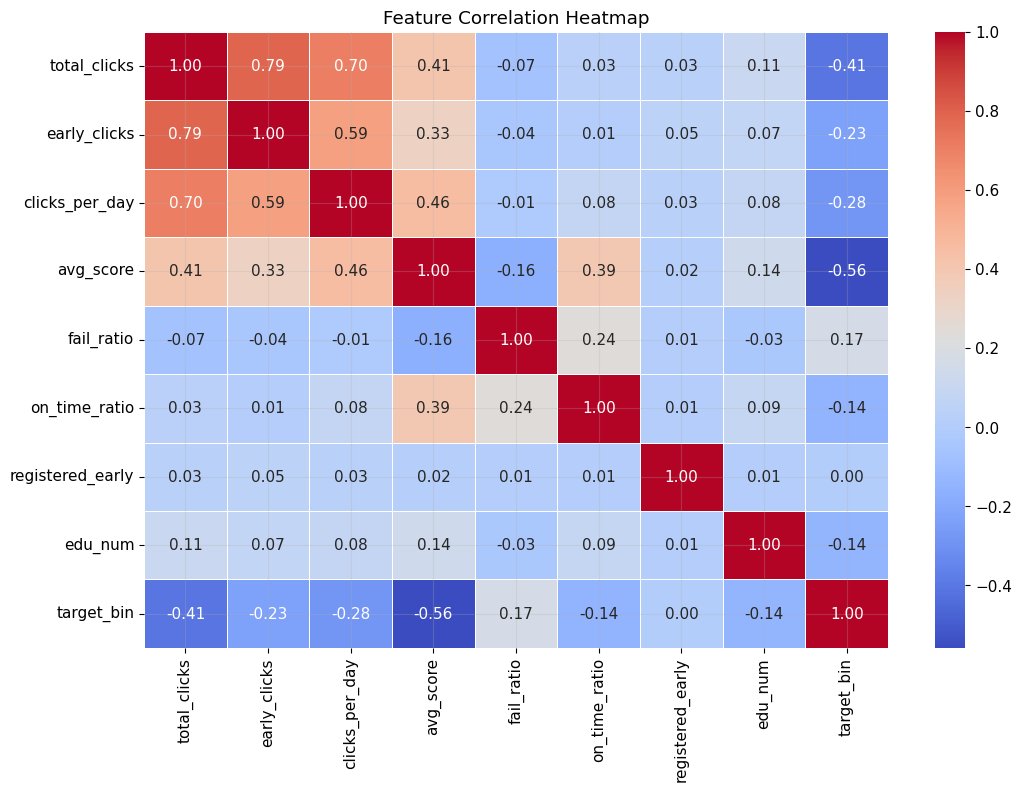

target_bin          1.000
fail_ratio          0.168
registered_early    0.003
edu_num            -0.144
on_time_ratio      -0.145
early_clicks       -0.231
clicks_per_day     -0.283
total_clicks       -0.412
avg_score          -0.559
Name: target_bin, dtype: float64


In [44]:
# target encoding
master['target_bin'] = master['final_result'].map({
    'Pass': 0,
    'Distinction': 0,
    'Fail': 1,
    'Withdrawn': 1
})

# Correlation Heatmap

# nختار أهم ال features
cols = [
    # Engagement
    'total_clicks',
    'early_clicks',
    'clicks_per_day',

    # Assessment
    'avg_score',
    'fail_ratio',
    'on_time_ratio',

    # Registration
    'registered_early',

    # Demographics
    'edu_num',
    'imd_num',
    'age_num',

    # Target
    'target_bin'
]

#Checking Existing Columns
cols = [c for c in cols if c in master.columns]

# nحسب correlation
corr = master[cols].corr()

# figure size
plt.figure(figsize=(12,8))

# رسم heatmap
sns.heatmap(
    corr,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    linewidths=0.5
)

# title
plt.title('Feature Correlation Heatmap')

# show plot
plt.show()

# correlation with target
target_corr = (
    corr['target_bin']
    .sort_values(ascending=False)
)

# print correlations
print(target_corr)

---
## SECTION 6 — Modeling Pipeline

In [19]:
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, learning_curve
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score, precision_score, recall_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay, RocCurveDisplay,
    precision_recall_curve, average_precision_score
)
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipe

In [20]:
# ── Train / Test split ───────────────────────────────────────
drop_cols = ['id_student', 'target_bin', 'target_4']
X = master.drop(columns=drop_cols, errors='ignore').select_dtypes(include=np.number)
y = master['target_bin']   # 0=success, 1=at-risk

# Remove any inf or extreme values
X = X.replace([np.inf, -np.inf], 0).fillna(0)

X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=.2, stratify=y, random_state=SEED)

print(f'Train : {X_tr.shape}  |  Test : {X_te.shape}')
print(f'Positive rate train : {y_tr.mean():.2%}  |  Positive rate test : {y_te.mean():.2%}') # at resk
print(f'Total features : {X_tr.shape[1]}')

Train : (26074, 28)  |  Test : (6519, 28)
Positive rate train : 52.80%  |  Positive rate test : 52.80%
Total features : 28


In [21]:
cv5 = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
def make_pipe(model, scale=False, sampler=None):
    """Leakage-safe pipeline: SMOTE inside CV fold only."""
    samp = sampler or SMOTE(random_state=SEED)
    steps = [('smote', samp)]
    # SMORE -> scaler if ture
    if scale:
        steps.append(('scaler', StandardScaler()))
    steps.append(('model', model))
    return ImbPipe(steps)

print('\n  Data split ready — pipelines configured')



  Data split ready — pipelines configured


In [23]:
# ── Model definitions ─Dictionary ─
MODELS = {
    'Logistic Regression': make_pipe(
        LogisticRegression(max_iter=1000, C=1.0, class_weight='balanced', random_state=SEED),
        scale=True),


    'Decision Tree': make_pipe(
        DecisionTreeClassifier(max_depth=8, min_samples_leaf=20,
                               class_weight='balanced', random_state=SEED)),

    'Random Forest': make_pipe(
        RandomForestClassifier(n_estimators=300, max_depth=15,
                               min_samples_leaf=10, class_weight='balanced',
                               n_jobs=-1, random_state=SEED)),

    'Gradient Boosting': make_pipe(
        GradientBoostingClassifier(n_estimators=200, learning_rate=.05,
                                   max_depth=5, random_state=SEED)),
    'XGBoost': make_pipe(
        xgb.XGBClassifier(n_estimators=300, learning_rate=.05, max_depth=6,
                           subsample=.8, colsample_bytree=.8,
                           eval_metric='logloss', random_state=SEED, n_jobs=-1)),

    #leaf wise not level wise
    'LightGBM': make_pipe(
        lgb.LGBMClassifier(n_estimators=300, learning_rate=.05, num_leaves=63,
                           subsample=.8, colsample_bytree=.8,
                           is_unbalance=True,
                           random_state=SEED, n_jobs=-1, verbose=-1)),

    'SVM': make_pipe(
        SVC(kernel='rbf', C=5, probability=True, class_weight='balanced',
            random_state=SEED), scale=True),

    'KNN': make_pipe(
        KNeighborsClassifier(n_neighbors=11, n_jobs=-1), scale=True),

    #pred -> error -> backpropagation -> update weight  
    #Multi layer perception -> backpropagation
    #relu + -> 1 , - -> 0
    'MLP Neural Net': make_pipe(
        MLPClassifier(hidden_layer_sizes=(256,128,64), activation='relu',
                      alpha=1e-3, learning_rate='adaptive',
                      max_iter=300, random_state=SEED), scale=True),
}


In [24]:
# ── Training loop ────────────────────────────────────────────
RESULTS = {}
print('\n  Training models …\n')

for name, pipe in MODELS.items():
    t0 = time.time() #start
    print(f' {name:<22}', end=' ', flush=True)
    pipe.fit(X_tr, y_tr)
    yp = pipe.predict(X_te)
    yprob = pipe.predict_proba(X_te)[:,1] #for AUC
    acc = accuracy_score(y_te, yp)
    f1 = f1_score(y_te, yp, average='weighted')
    prec = precision_score(y_te, yp, average='weighted', zero_division=0)
    rec = recall_score(y_te, yp, average='weighted')
    auc = roc_auc_score(y_te, yprob)
    ap = average_precision_score(y_te, yprob)
    cvf1 = cross_val_score(pipe, X_tr, y_tr, cv=cv5, scoring='f1_weighted', n_jobs=1).mean()
    elapsed = time.time() - t0  #end
    RESULTS[name] = {
        'Accuracy' : round(acc*100, 2),
        'Precision' : round(prec*100, 2),
        'Recall' : round(rec*100, 2),
        'F1 Weighted' : round(f1*100, 2),
        'ROC-AUC' : round(auc*100, 2),
        'Avg Precision' : round(ap*100, 2),
        'CV F1 (5-fold)': round(cvf1*100, 2),
    }
    print(f'Acc={acc:.3f}  F1={f1:.3f}  AUC={auc:.3f}  ({elapsed:.0f}s)')



  Training models …

 Logistic Regression    Acc=0.898  F1=0.898  AUC=0.959  (4s)
 Decision Tree          Acc=0.910  F1=0.910  AUC=0.970  (3s)
 Random Forest          Acc=0.910  F1=0.910  AUC=0.975  (19s)
 Gradient Boosting      Acc=0.914  F1=0.914  AUC=0.978  (129s)
 XGBoost                Acc=0.911  F1=0.911  AUC=0.977  (7s)
 LightGBM               Acc=0.908  F1=0.908  AUC=0.976  (10s)
 SVM                    Acc=0.910  F1=0.910  AUC=0.968  (269s)
 KNN                    Acc=0.899  F1=0.899  AUC=0.962  (3s)
 MLP Neural Net         Acc=0.886  F1=0.886  AUC=0.964  (416s)


---
##  SECTION 7 — Hyperparameter Tuning with Optuna

In [25]:
# ── Tune the best tree model with Optuna ─────────────────────
res_df = pd.DataFrame(RESULTS).T.sort_values('F1 Weighted', ascending=False)
best_name = res_df['F1 Weighted'].idxmax()
print(f' Tuning best model: {best_name}\n')


 Tuning best model: Gradient Boosting



In [26]:
def objective_lgbm(trial):
    params = dict(
        n_estimators = trial.suggest_int('n_estimators', 100, 600),
        learning_rate = trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
        num_leaves = trial.suggest_int('num_leaves', 20, 150),
        max_depth = trial.suggest_int('max_depth', 3, 12),
        subsample = trial.suggest_float('subsample', 0.5, 1.0),
        colsample_bytree = trial.suggest_float('colsample_bytree', 0.5, 1.0),
        reg_alpha = trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),
        reg_lambda = trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True),
        min_child_samples = trial.suggest_int('min_child_samples', 10, 100),
    )
    model = lgb.LGBMClassifier(**params, is_unbalance=True,
                                random_state=SEED, n_jobs=-1, verbose=-1)
    pipe  = make_pipe(model)
    score = cross_val_score(pipe, X_tr, y_tr, cv=3,
                            scoring='roc_auc', n_jobs=1).mean()
    return score

def objective_xgb(trial):
    params = dict(
        n_estimators = trial.suggest_int('n_estimators', 100, 600),
        learning_rate = trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
        max_depth = trial.suggest_int('max_depth', 3, 10),
        subsample = trial.suggest_float('subsample', 0.5, 1.0),
        colsample_bytree = trial.suggest_float('colsample_bytree', 0.5, 1.0),
        gamma = trial.suggest_float('gamma', 0, 5),
        reg_alpha = trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),
        reg_lambda = trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True),
    )
    model = xgb.XGBClassifier(**params, eval_metric='logloss',
                               random_state=SEED, n_jobs=-1)
    pipe  = make_pipe(model)
    score = cross_val_score(pipe, X_tr, y_tr, cv=3,
                            scoring='roc_auc', n_jobs=1).mean()
    return score

# Run Optuna (25 trials each)
print('Tuning LightGBM …')
study_lgb = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=SEED))
study_lgb.optimize(objective_lgbm, n_trials=25, show_progress_bar=True)
print(f'  Best LightGBM AUC: {study_lgb.best_value:.4f}')

print('\nTuning XGBoost …')
study_xgb = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=SEED))
study_xgb.optimize(objective_xgb, n_trials=25, show_progress_bar=True)
print(f'  Best XGBoost  AUC: {study_xgb.best_value:.4f}')


Tuning LightGBM …


  0%|          | 0/25 [00:00<?, ?it/s]

  Best LightGBM AUC: 0.9773

Tuning XGBoost …


  0%|          | 0/25 [00:00<?, ?it/s]

  Best XGBoost  AUC: 0.9777


In [27]:
# ── Train tuned models ───────────────────────────────────────
print('\n Training tuned models on full training set …\n')

tuned_lgb = make_pipe(
    lgb.LGBMClassifier(**study_lgb.best_params, is_unbalance=True,
                        random_state=SEED, n_jobs=-1, verbose=-1))
tuned_lgb.fit(X_tr, y_tr)

tuned_xgb = make_pipe(
    xgb.XGBClassifier(**study_xgb.best_params, eval_metric='logloss',
                       random_state=SEED, n_jobs=-1))
tuned_xgb.fit(X_tr, y_tr)

for tag, pipe in [('LightGBM (Tuned)', tuned_lgb), ('XGBoost (Tuned)', tuned_xgb)]:
    yp    = pipe.predict(X_te)
    yprob = pipe.predict_proba(X_te)[:,1]
    acc   = accuracy_score(y_te, yp)
    f1    = f1_score(y_te, yp, average='weighted')
    prec  = precision_score(y_te, yp, average='weighted', zero_division=0)
    rec   = recall_score(y_te, yp, average='weighted')
    auc   = roc_auc_score(y_te, yprob)
    ap    = average_precision_score(y_te, yprob)
    cvf1  = cross_val_score(pipe, X_tr, y_tr, cv=cv5, scoring='f1_weighted', n_jobs=1).mean()
    RESULTS[tag] = {
        'Accuracy'      : round(acc*100, 2),
        'Precision'     : round(prec*100, 2),
        'Recall'        : round(rec*100, 2),
        'F1 Weighted'   : round(f1*100, 2),
        'ROC-AUC'       : round(auc*100, 2),
        'Avg Precision' : round(ap*100, 2),
        'CV F1 (5-fold)': round(cvf1*100, 2),
    }
    MODELS[tag] = pipe
    print(f'  {tag:<25}  Acc={acc:.3f}  F1={f1:.3f}  AUC={auc:.3f}')

# Update best
res_df    = pd.DataFrame(RESULTS).T.sort_values('F1 Weighted', ascending=False)
best_name = res_df['F1 Weighted'].idxmax()
best_pipe = MODELS[best_name]
print(f'\n  Best overall model: {best_name}')



 Training tuned models on full training set …

  LightGBM (Tuned)           Acc=0.916  F1=0.916  AUC=0.979
  XGBoost (Tuned)            Acc=0.920  F1=0.920  AUC=0.979

  Best overall model: XGBoost (Tuned)


---
##  SECTION 8 — Evaluation & Advanced Visualizations


 MODEL COMPARISON TABLE (sorted by F1 Weighted)
                     Accuracy  Precision  Recall  F1 Weighted  ROC-AUC  Avg Precision  CV F1 (5-fold)
XGBoost (Tuned)        92.010     92.030  92.010       92.010   97.920         98.360          92.160
LightGBM (Tuned)       91.610     91.660  91.610       91.610   97.870         98.310          91.800
Gradient Boosting      91.410     91.450  91.410       91.410   97.780         98.240          91.590
XGBoost                91.090     91.140  91.090       91.090   97.730         98.190          91.280
Random Forest          91.000     91.050  91.000       91.000   97.530         98.040          91.150
SVM                    90.980     91.060  90.980       90.990   96.840         97.650          91.040
Decision Tree          90.960     90.980  90.960       90.970   97.020         97.430          91.330
LightGBM               90.750     90.820  90.750       90.760   97.640         98.120          90.910
KNN                    89.880    

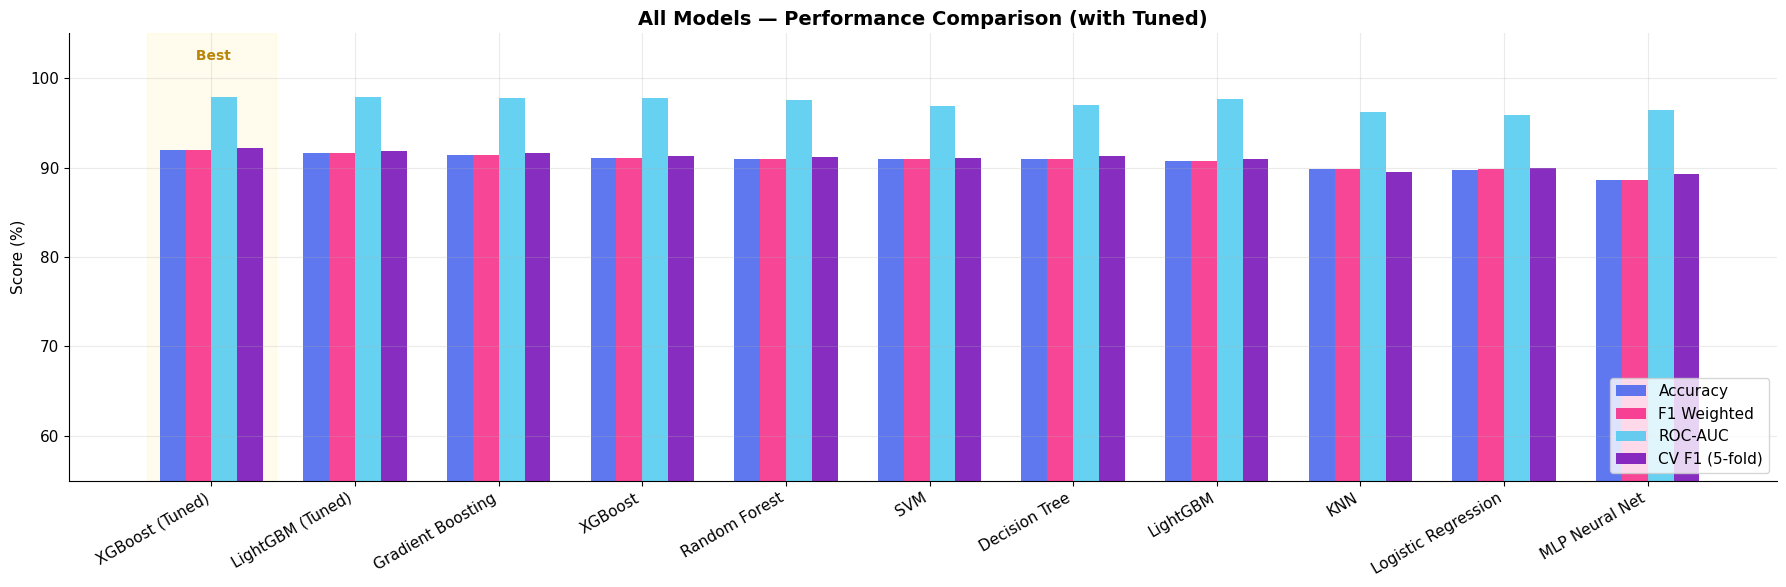

In [28]:
# ── Fig 8 · Model comparison bar chart ──────────────────────
res_df = pd.DataFrame(RESULTS).T.sort_values('F1 Weighted', ascending=False)
print('\n' + '='*70)
print(' MODEL COMPARISON TABLE (sorted by F1 Weighted)')
print('='*70)
print(res_df.to_string())
print(f'\n  Best model: {best_name}')

metrics  = ['Accuracy','F1 Weighted','ROC-AUC','CV F1 (5-fold)']
n, w     = len(res_df), 0.18

fig, ax = plt.subplots(figsize=(18, 6))
x = np.arange(n)
for i, (m, col) in enumerate(zip(metrics, CLR['palette'][:4])):
    bars = ax.bar(x + i*w - w*1.5, res_df[m], w, label=m, color=col, alpha=.85)

ax.set_xticks(x)
ax.set_xticklabels(res_df.index, rotation=30, ha='right')
ax.set_ylabel('Score (%)')
ax.set_title('All Models — Performance Comparison (with Tuned)', fontsize=14, fontweight='bold')
ax.set_ylim(55, 105)
ax.legend(loc='lower right')
# Highlight best
best_idx = list(res_df.index).index(best_name)
ax.axvspan(best_idx - 0.45, best_idx + 0.45, alpha=0.07, color='gold', zorder=0)
ax.annotate(' Best', (best_idx, 102), ha='center', fontsize=10, color='darkgoldenrod', fontweight='bold')

plt.tight_layout()
plt.savefig('fig08_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()


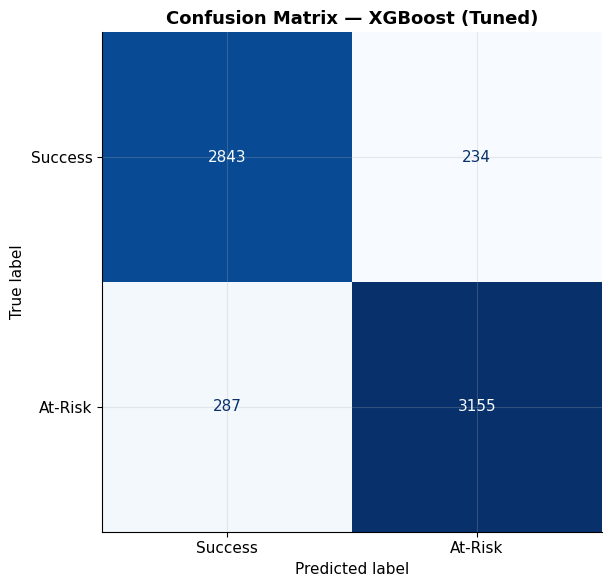

              precision    recall  f1-score   support

     Success       0.91      0.92      0.92      3077
     At-Risk       0.93      0.92      0.92      3442

    accuracy                           0.92      6519
   macro avg       0.92      0.92      0.92      6519
weighted avg       0.92      0.92      0.92      6519



In [29]:
# ── Fig 9 · Confusion matrix ─────────────────────────────────
yp_best = best_pipe.predict(X_te)

fig, ax = plt.subplots(figsize=(7, 6))
cm = confusion_matrix(y_te, yp_best)
ConfusionMatrixDisplay(cm, display_labels=['Success','At-Risk']).plot(
    ax=ax, colorbar=False, cmap='Blues')
ax.set_title(f'Confusion Matrix — {best_name}', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig09_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print(classification_report(y_te, yp_best, target_names=['Success','At-Risk']))


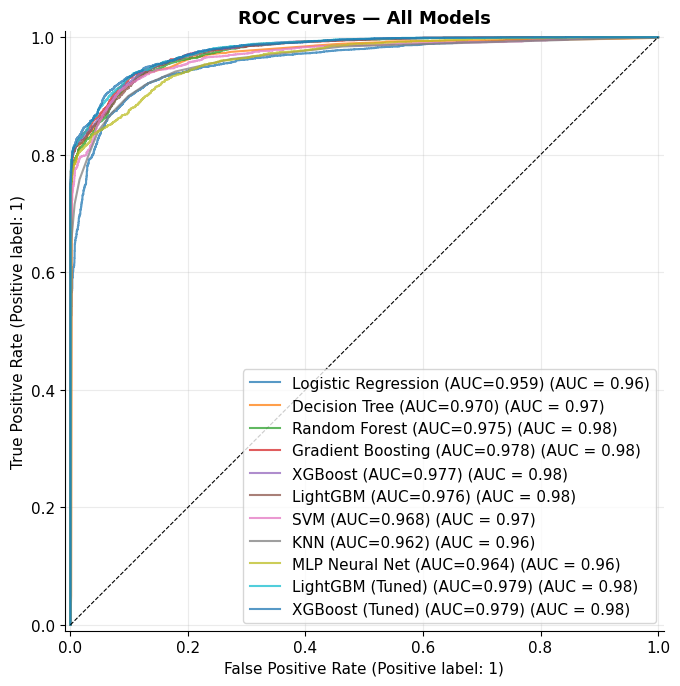

In [30]:
# ── Fig 10 · ROC curves ─────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 7))
for name, pipe in MODELS.items():
    prob = pipe.predict_proba(X_te)[:,1]
    auc  = roc_auc_score(y_te, prob)
    RocCurveDisplay.from_predictions(y_te, prob,
                                      name=f'{name} (AUC={auc:.3f})',
                                      ax=ax, alpha=.75)
ax.plot([0,1],[0,1],'k--', lw=.8)
ax.set_title('ROC Curves — All Models', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig10_roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()


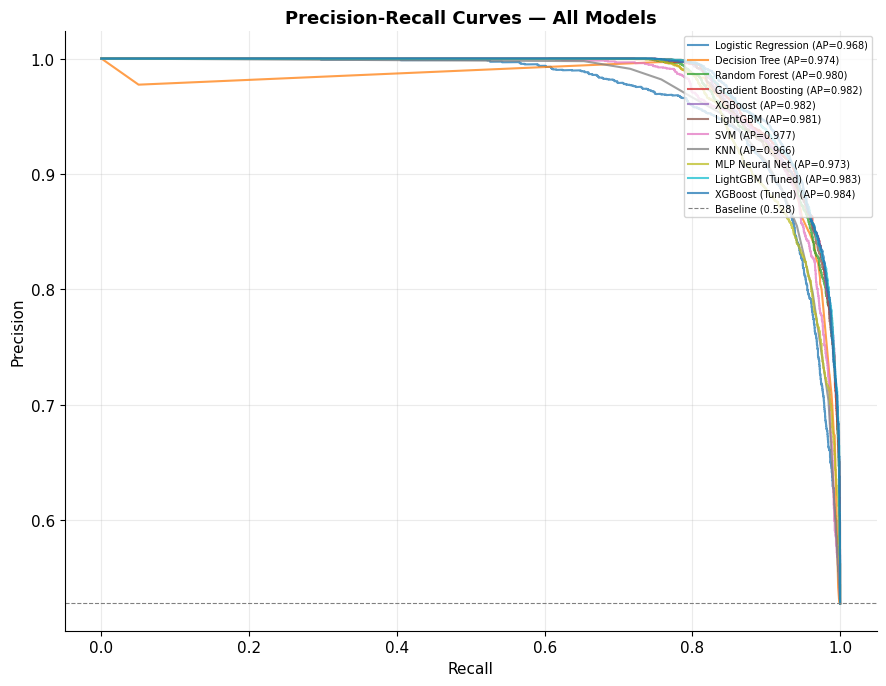

In [31]:
# ── Fig 11 · Precision-Recall curves ────────────────────────
fig, ax = plt.subplots(figsize=(9, 7))
for name, pipe in MODELS.items():
    prob = pipe.predict_proba(X_te)[:,1]
    ap   = average_precision_score(y_te, prob)
    prec_c, rec_c, _ = precision_recall_curve(y_te, prob)
    ax.plot(rec_c, prec_c, lw=1.5, alpha=.75, label=f'{name} (AP={ap:.3f})')

baseline = y_te.mean()
ax.axhline(baseline, color='gray', ls='--', lw=.8, label=f'Baseline ({baseline:.3f})')
ax.set_xlabel('Recall'); ax.set_ylabel('Precision')
ax.set_title('Precision-Recall Curves — All Models', fontsize=13, fontweight='bold')
ax.legend(fontsize=7, loc='upper right')
plt.tight_layout()
plt.savefig('fig11_pr_curves.png', dpi=150, bbox_inches='tight')
plt.show()


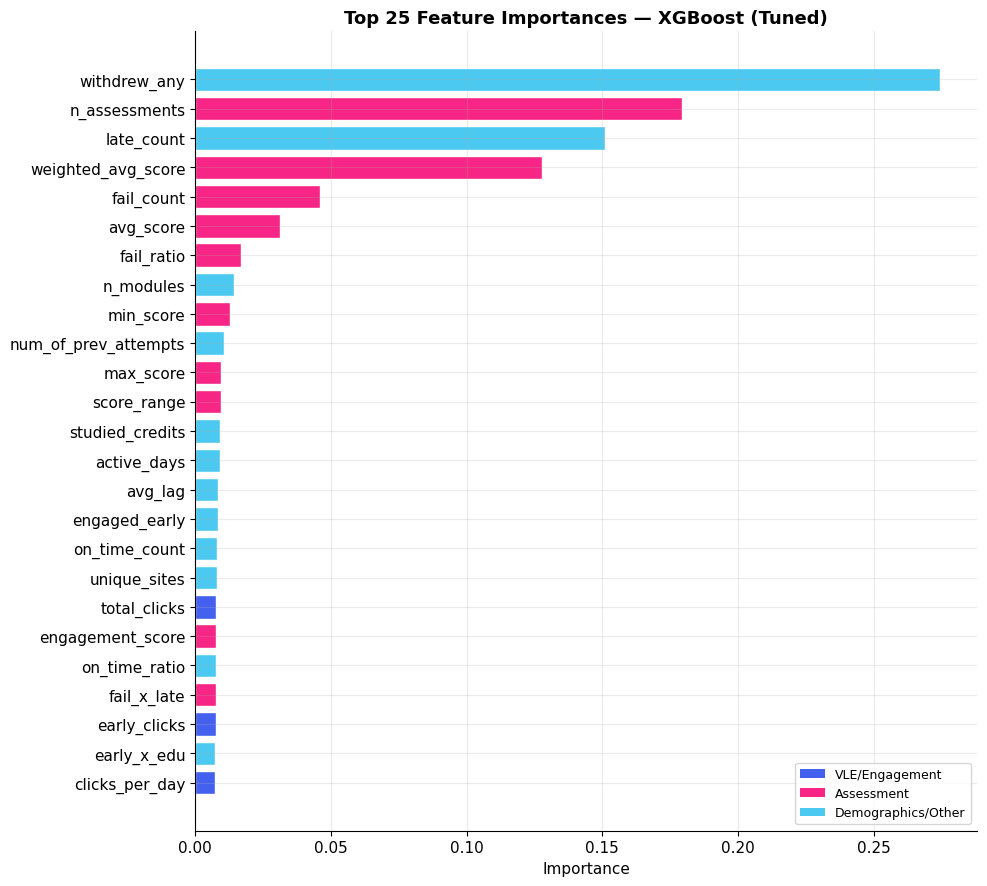

In [32]:
# ── Fig 12 · Feature importance ─────────────────────────────
tree_models = ['LightGBM (Tuned)','XGBoost (Tuned)','LightGBM','XGBoost',
               'Random Forest','Gradient Boosting']
best_tree   = next((m for m in res_df.index if m in tree_models), None)

if best_tree:
    fi = MODELS[best_tree].named_steps['model'].feature_importances_
    fi_df = (pd.DataFrame({'feature': X_tr.columns, 'importance': fi})
               .sort_values('importance', ascending=False)
               .head(25))

    fig, ax = plt.subplots(figsize=(10, 9))
    colors  = [CLR['palette'][0] if 'click' in f or 'vle' in f or 'act_' in f
               else CLR['palette'][1] if 'score' in f or 'assess' in f or 'fail' in f
               else CLR['palette'][2]
               for f in fi_df['feature']]
    ax.barh(fi_df['feature'][::-1], fi_df['importance'][::-1],
            color=colors[::-1], edgecolor='white')
    ax.set_xlabel('Importance')
    ax.set_title(f'Top 25 Feature Importances — {best_tree}', fontsize=13, fontweight='bold')
    # Legend for color coding
    from matplotlib.patches import Patch
    legend_elems = [Patch(facecolor=CLR['palette'][0], label='VLE/Engagement'),
                    Patch(facecolor=CLR['palette'][1], label='Assessment'),
                    Patch(facecolor=CLR['palette'][2], label='Demographics/Other')]
    ax.legend(handles=legend_elems, loc='lower right', fontsize=9)
    plt.tight_layout()
    plt.savefig('fig12_feature_importance.png', dpi=150, bbox_inches='tight')
    plt.show()



  Computing learning curves for XGBoost (Tuned) …


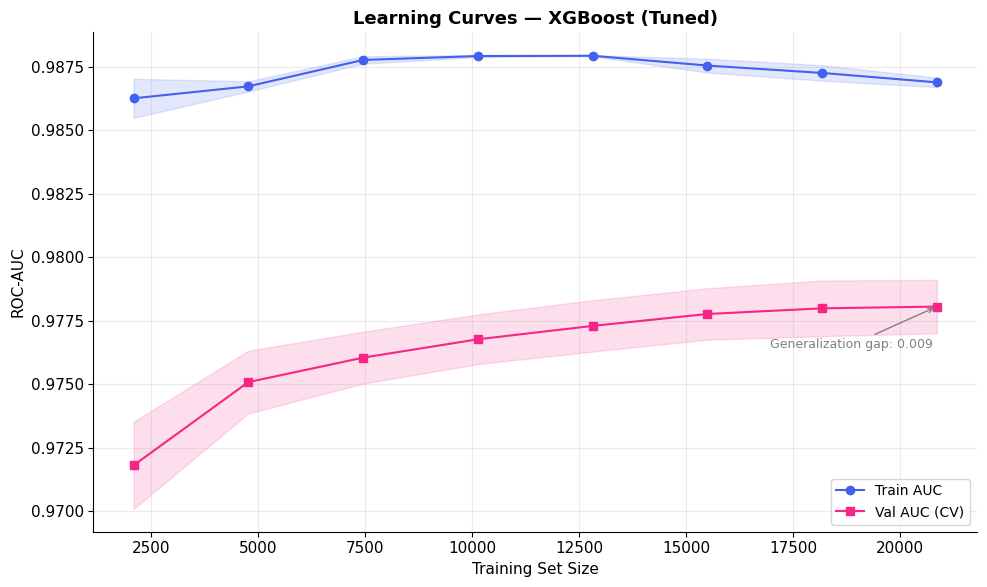

  Generalization gap (train-val AUC): 0.009
  → Good generalization 


In [33]:
# ── Fig 13 · Learning curves ─────────────────────────────────
print(f'\n  Computing learning curves for {best_name} …')

train_sizes, train_scores, val_scores = learning_curve(
    best_pipe, X_tr, y_tr,
    train_sizes=np.linspace(.1, 1.0, 8),
    cv=5, scoring='roc_auc',
    n_jobs=1, random_state=SEED
)

fig, ax = plt.subplots(figsize=(10, 6))
tr_mean, tr_std = train_scores.mean(axis=1), train_scores.std(axis=1)
vl_mean, vl_std = val_scores.mean(axis=1),   val_scores.std(axis=1)

ax.plot(train_sizes, tr_mean, 'o-', color=CLR['palette'][0], label='Train AUC')
ax.fill_between(train_sizes, tr_mean-tr_std, tr_mean+tr_std, alpha=.15, color=CLR['palette'][0])
ax.plot(train_sizes, vl_mean, 's-', color=CLR['palette'][1], label='Val AUC (CV)')
ax.fill_between(train_sizes, vl_mean-vl_std, vl_mean+vl_std, alpha=.15, color=CLR['palette'][1])

gap = tr_mean[-1] - vl_mean[-1]
ax.set_xlabel('Training Set Size'); ax.set_ylabel('ROC-AUC')
ax.set_title(f'Learning Curves — {best_name}', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.annotate(f'Generalization gap: {gap:.3f}',
            xy=(train_sizes[-1], vl_mean[-1]),
            xytext=(-120, -30), textcoords='offset points',
            arrowprops=dict(arrowstyle='->', color='gray'),
            fontsize=9, color='gray')

plt.tight_layout()
plt.savefig('fig13_learning_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'  Generalization gap (train-val AUC): {gap:.3f}')
print(f'  → {"Slight overfitting" if gap > 0.05 else "Good generalization "}')


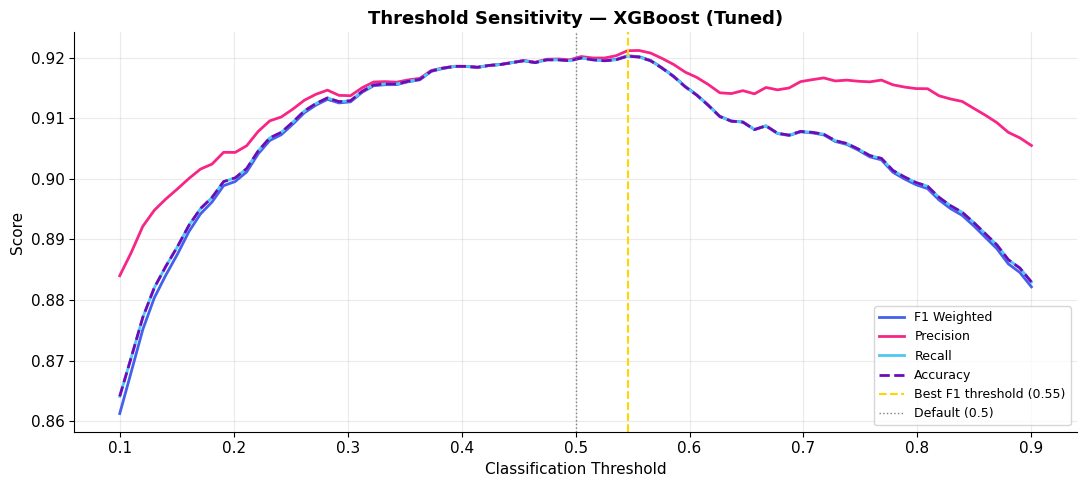


  Optimal threshold for F1  : 0.55
    F1 @ default (0.5)         : 0.919
    F1 @ optimal (0.55)       : 0.920


In [34]:
# ── Fig 14 · Threshold optimization ─────────────────────────
yprob_best = best_pipe.predict_proba(X_te)[:,1]
thresholds = np.linspace(0.1, 0.9, 80)

f1s, precs, recs, accs = [], [], [], []
for t in thresholds:
    yp_t = (yprob_best >= t).astype(int)
    f1s.append(f1_score(y_te, yp_t, average='weighted', zero_division=0))
    precs.append(precision_score(y_te, yp_t, average='weighted', zero_division=0))
    recs.append(recall_score(y_te, yp_t, average='weighted', zero_division=0))
    accs.append(accuracy_score(y_te, yp_t))

best_t_f1  = thresholds[np.argmax(f1s)]
best_t_rec = thresholds[np.argmax(recs)]

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(thresholds, f1s,   label='F1 Weighted',  color=CLR['palette'][0], lw=2)
ax.plot(thresholds, precs, label='Precision',     color=CLR['palette'][1], lw=2)
ax.plot(thresholds, recs,  label='Recall',        color=CLR['palette'][2], lw=2)
ax.plot(thresholds, accs,  label='Accuracy',      color=CLR['palette'][3], lw=2, ls='--')
ax.axvline(best_t_f1, color='gold', lw=1.5, ls='--', label=f'Best F1 threshold ({best_t_f1:.2f})')
ax.axvline(0.5, color='gray', lw=1, ls=':', label='Default (0.5)')
ax.set_xlabel('Classification Threshold'); ax.set_ylabel('Score')
ax.set_title(f'Threshold Sensitivity — {best_name}', fontsize=13, fontweight='bold')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig('fig14_threshold_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\n  Optimal threshold for F1  : {best_t_f1:.2f}')
print(f'    F1 @ default (0.5)         : {f1s[np.argmin(np.abs(thresholds-0.5))]:.3f}')
print(f'    F1 @ optimal ({best_t_f1:.2f})       : {max(f1s):.3f}')


---
##  SECTION 9 — SHAP Explainability


  Computing SHAP values for XGBoost (Tuned) …


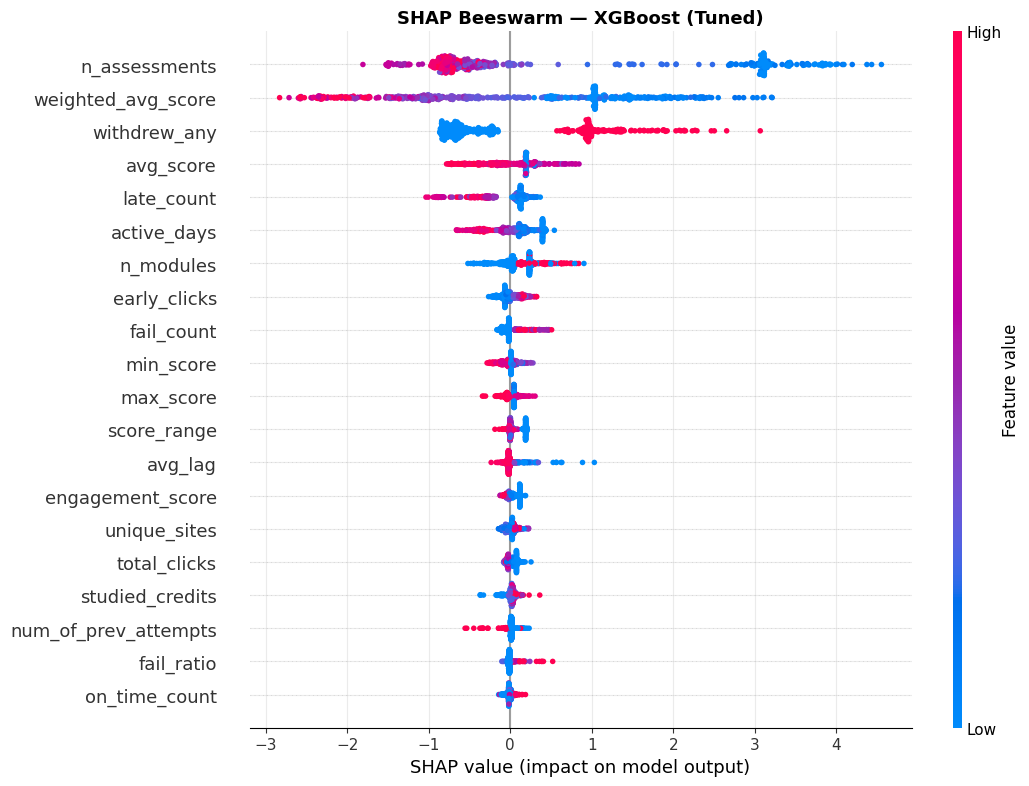

In [35]:
import shap
shap.initjs()

print(f'\n  Computing SHAP values for {best_tree} …')
X_sample  = X_te.sample(min(500, len(X_te)), random_state=SEED)
explainer  = shap.TreeExplainer(MODELS[best_tree].named_steps['model'])
sv_vals    = explainer.shap_values(X_sample)
shap_arr   = sv_vals if not isinstance(sv_vals, list) else sv_vals[1]

# Fig 15 · SHAP beeswarm
shap.summary_plot(shap_arr, X_sample, show=False, plot_size=(11, 8))
plt.title(f'SHAP Beeswarm — {best_tree}', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig15_shap_beeswarm.png', dpi=150, bbox_inches='tight')
plt.show()


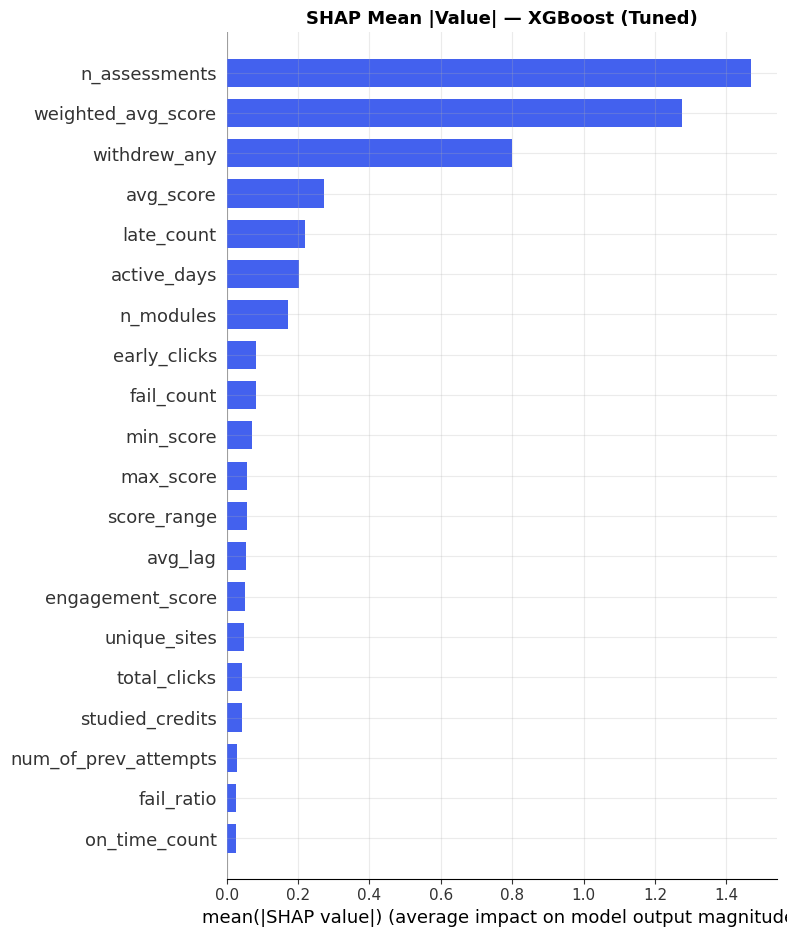

In [36]:
# Fig 16 · SHAP mean bar
shap.summary_plot(shap_arr, X_sample, plot_type='bar', show=False, color=CLR['palette'][0])
plt.title(f'SHAP Mean |Value| — {best_tree}', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig16_shap_bar.png', dpi=150, bbox_inches='tight')
plt.show()


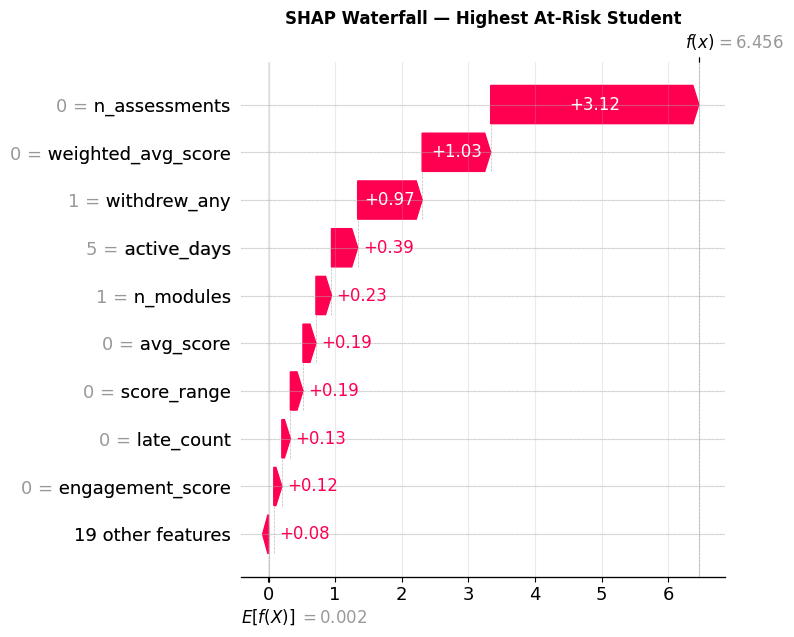

In [37]:
# Fig 17 · SHAP waterfall — at-risk student
exp_obj = explainer(X_sample)
# Find a predicted at-risk student for illustration
probs_sample = best_pipe.predict_proba(X_sample)[:,1]
idx_atrisk   = np.argmax(probs_sample)

shap.plots.waterfall(exp_obj[idx_atrisk], show=False)
plt.title(f'SHAP Waterfall — Highest At-Risk Student', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('fig17_shap_waterfall_atrisk.png', dpi=150, bbox_inches='tight')
plt.show()


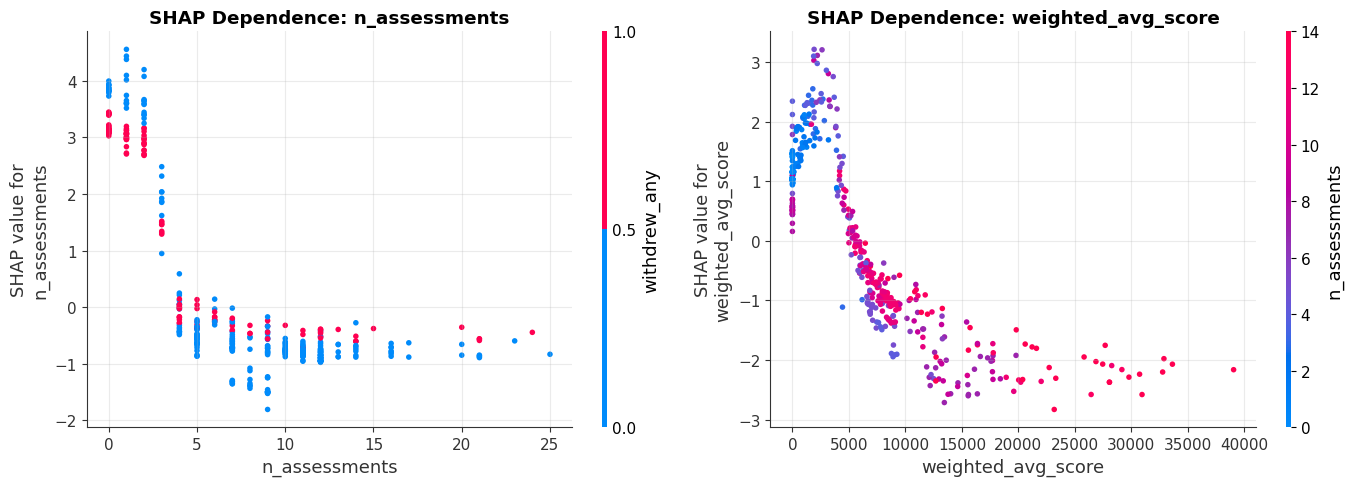


  SHAP analysis complete — 4 figures saved (fig15–18)


In [38]:
# Fig 18 · SHAP dependence plot — top 2 features
top2 = pd.DataFrame({'feat': X_sample.columns,
                     'imp': np.abs(shap_arr).mean(0)}).nlargest(2, 'imp')['feat'].tolist()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, feat in zip(axes, top2):
    feat_idx = list(X_sample.columns).index(feat)
    shap.dependence_plot(feat, shap_arr, X_sample, ax=ax, show=False)
    ax.set_title(f'SHAP Dependence: {feat}', fontweight='bold')

plt.tight_layout()
plt.savefig('fig18_shap_dependence.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'\n  SHAP analysis complete — 4 figures saved (fig15–18)')


---
##  SECTION 10 — Ensemble Voting Classifier

In [39]:
# ── Soft-voting ensemble of top 3 models ────────────────────
print('\n  Building ensemble from top 3 models …\n')

top3 = res_df.head(3).index.tolist()
print(f'  Top 3: {top3}')

# Extract base estimators (already fitted)
# For voting, retrain on full training set
ensemble_estimators = []
for name in top3:
    pipe = MODELS[name]
    ensemble_estimators.append((name.replace(' ','_'), pipe))

# VotingClassifier doesn't support ImbPipeline directly,
# so we use the already-fitted models and predict_proba manually

proba_ensemble = np.zeros(len(X_te))
for name in top3:
    proba_ensemble += MODELS[name].predict_proba(X_te)[:,1]
proba_ensemble /= len(top3)

yp_ens = (proba_ensemble >= best_t_f1).astype(int)  # use optimal threshold

ens_acc = accuracy_score(y_te, yp_ens)
ens_f1  = f1_score(y_te, yp_ens, average='weighted')
ens_auc = roc_auc_score(y_te, proba_ensemble)
ens_ap  = average_precision_score(y_te, proba_ensemble)

RESULTS['Ensemble (Top3)'] = {
    'Accuracy'      : round(ens_acc*100, 2),
    'Precision'     : round(precision_score(y_te,yp_ens,average='weighted',zero_division=0)*100, 2),
    'Recall'        : round(recall_score(y_te,yp_ens,average='weighted')*100, 2),
    'F1 Weighted'   : round(ens_f1*100, 2),
    'ROC-AUC'       : round(ens_auc*100, 2),
    'Avg Precision' : round(ens_ap*100, 2),
    'CV F1 (5-fold)': 0.0,   # N/A for manual ensemble
}
print(f'  Ensemble  →  Acc={ens_acc:.3f}  F1={ens_f1:.3f}  AUC={ens_auc:.3f}')
print(f'\n  Ensemble built with optimal threshold ({best_t_f1:.2f})')



  Building ensemble from top 3 models …

  Top 3: ['XGBoost (Tuned)', 'LightGBM (Tuned)', 'Gradient Boosting']
  Ensemble  →  Acc=0.915  F1=0.915  AUC=0.979

  Ensemble built with optimal threshold (0.55)


In [40]:
# ── Fig 19 · Final results radar chart ──────────────────────
final_df = pd.DataFrame(RESULTS).T
metrics_radar = ['Accuracy','F1 Weighted','ROC-AUC','Avg Precision','Recall']

top5 = final_df.sort_values('F1 Weighted', ascending=False).head(5)

fig = go.Figure()
for i, (idx, row) in enumerate(top5.iterrows()):
    vals = [row[m] for m in metrics_radar]
    vals += vals[:1]  # close polygon
    cats  = metrics_radar + metrics_radar[:1]
    fig.add_trace(go.Scatterpolar(
        r=vals, theta=cats, fill='toself',
        name=idx, line_color=CLR['palette'][i], opacity=.75
    ))

fig.update_layout(
    polar=dict(radialaxis=dict(visible=True, range=[60,100])),
    title='Top 5 Models — Radar Comparison',
    showlegend=True, height=550
)
fig.write_image('fig19_radar_comparison.png', width=700, height=550, scale=2)
fig.show()


---
##  SECTION 11 — Save All Artifacts

In [41]:
import joblib

joblib.dump(best_pipe,               'best_model.pkl')
joblib.dump(MODELS,                  'all_models.pkl')
joblib.dump(X_tr.columns.tolist(),   'feature_names.pkl')
joblib.dump(RESULTS,                 'all_results.pkl')
joblib.dump({'threshold': best_t_f1, 'best_model': best_name}, 'config.pkl')

print('\n ARTIFACTS SAVED')
print('─'*55)
print('  best_model.pkl       → Best prediction pipeline')
print('  all_models.pkl       → All trained pipelines')
print('  feature_names.pkl    → Column order for inference')
print('  all_results.pkl      → Model metrics table')
print('  encoders.pkl         → Fitted label encoders')
print('  config.pkl           → Optimal threshold + model name')
print('  master.parquet       → Full feature-engineered dataset')

print('\n' + '='*65)
print(' PROJECT COMPLETE — OULAD FULL FEATURE EXTRACTION PIPELINE')
print('='*65)
print(f'  Students              : {len(master):,}')
print(f'  Total Features        : {X.shape[1]}')
print(f'  Models Trained        : {len(MODELS)}')
print(f'  Optuna Trials         : 25 LightGBM + 25 XGBoost')
print(f'  Best Model            : {best_name}')
print(f'  Accuracy              : {RESULTS[best_name]["Accuracy"]:.2f}%')
print(f'  F1 Weighted           : {RESULTS[best_name]["F1 Weighted"]:.2f}%')
print(f'  ROC-AUC               : {RESULTS[best_name]["ROC-AUC"]:.2f}%')
print(f'  CV F1 (5-fold)        : {RESULTS[best_name]["CV F1 (5-fold)"]:.2f}%')
print(f'  Optimal Threshold     : {best_t_f1:.2f}')
print(f'\n  Tables Exploited      : 7 / 7  ')
print(f'  NEW features added:')
print(f' clicks_per_week       (courses → module_presentation_length)')
print(f' active_day_ratio      (courses → module_presentation_length)')
print(f' on_schedule_ratio     (vle → week_from / week_to)')
print(f' avg_reg_timing        (studentRegistration → date_registration)')
print(f' registered_early      (studentRegistration → date_registration)')
print(f' avg_days_before       (studentRegistration → date_registration)')
print(f' 4 cross-table interactions')
print(f'\n  Figures saved         : fig01 → fig19 (PNG, 150 dpi)')
print(f'  Encoding              : Ordinal + Binary + LabelEnc + OneHot ')
print(f'  Tuning                : Optuna TPE (50 total trials)         ')
print(f'  Explainability        : SHAP beeswarm + bar + waterfall + dep')
print(f'  Ensemble              : Soft-voting Top-3 + optimal threshold')
print('='*65)



 ARTIFACTS SAVED
───────────────────────────────────────────────────────
  best_model.pkl       → Best prediction pipeline
  all_models.pkl       → All trained pipelines
  feature_names.pkl    → Column order for inference
  all_results.pkl      → Model metrics table
  encoders.pkl         → Fitted label encoders
  config.pkl           → Optimal threshold + model name
  master.parquet       → Full feature-engineered dataset

 PROJECT COMPLETE — OULAD FULL FEATURE EXTRACTION PIPELINE
  Students              : 32,593
  Total Features        : 28
  Models Trained        : 11
  Optuna Trials         : 25 LightGBM + 25 XGBoost
  Best Model            : XGBoost (Tuned)
  Accuracy              : 92.01%
  F1 Weighted           : 92.01%
  ROC-AUC               : 97.92%
  CV F1 (5-fold)        : 92.16%
  Optimal Threshold     : 0.55

  Tables Exploited      : 7 / 7  
  NEW features added:
 clicks_per_week       (courses → module_presentation_length)
 active_day_ratio      (courses → module_prese